In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import DiadFit as pf
pf.__version__
import os
import re

In [45]:
plt.rcParams["font.family"] = 'arial'
plt.rcParams["font.size"] =10
plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "dejavusans"
plt.rcParams['patch.linewidth'] = 1
plt.rcParams['axes.linewidth'] = 1
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4 # Sets length of ticks
plt.rcParams["ytick.major.size"] = 2 # Sets length of ticks
plt.rcParams["ytick.labelsize"] = 10 # Sets size of numbers on tick marks
plt.rcParams["xtick.labelsize"] = 10 # Sets size of numbers on tick marks
plt.rcParams["axes.titlesize"] = 11 # Overall title
plt.rcParams["axes.labelsize"] = 11 # Axes labels
plt.rcParams["axes.labelpad"] = 1

In [46]:
def calculate_HB_area(df):
    HB_diad=(df['HB2_Area']+df['HB1_Area'])/((df['Diad1_Voigt_Area']+df['Diad2_Voigt_Area']))
    return HB_diad

In [47]:
def extract_temperature(filename):
    match = re.search(r'(\d+)C', filename)
    if match:
        return int(match.group(1))
    else:
        return None

## Now lets load the tidy dataframe from the supplement

In [48]:
df=pd.read_excel(r'C:\Users\penny\Box\Berkeley_new\Raman\Raman technical paper\Supporting_information_Draft1.xlsx',
                 sheet_name='Combined_power_heating_series')

df_heat=df.loc[df['Series_Type']=='heat']
df_power=df.loc[df['Series_Type']=='power']

## Splitting into main text and supplement text

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- utilities ---
def mm_to_inches(mm): 
    return mm / 25.4

def compute_axes(T_heat, P_power, scale, offset):
    T_min_pad = T_heat.min() - 5
    T_max_pad = T_heat.max() + 5
    T_from_P_min = scale * P_power.min() + offset
    T_from_P_max = scale * P_power.max() + offset
    T_final_min = min(T_min_pad, T_from_P_min)
    T_final_max = max(T_max_pad, T_from_P_max)
    P_final_min = (T_final_min - offset) / scale
    P_final_max = (T_final_max - offset) / scale
    return (T_final_min, T_final_max), (P_final_min, P_final_max)

def plot_panel(ax, name, is_left):
    twin_ax = ax.twiny()

    heat = df_heat[df_heat['Series_Name'].str.contains(name)]
    power = df_power[df_power['Series_Name'].str.contains(name)]

    # --- Heating data ---
    ax.errorbar(heat['T (C)'], heat['Density g/cm3'],
                yerr=heat['σ Density g/cm3'],
                fmt='o', ecolor='k', elinewidth=0.8,
                mfc='red', ms=5, mec='k', capsize=3)

    # --- Power data ---
    twin_ax.errorbar(power['power (mW)'], power['Density g/cm3'],
                     yerr=power['σ Density g/cm3'],
                     fmt='d', ecolor='k', elinewidth=0.8,
                     mfc='cyan', ms=5, mec='k', capsize=3, zorder=100)

    # --- Fits (use proper stderr fields) ---
    res_h = linregress(heat['T (C)'], heat['Density g/cm3'])
    res_p = linregress(power['power (mW)'], power['Density g/cm3'])
    slope_h, intercept_h, stderr_h = res_h.slope, res_h.intercept, res_h.stderr
    slope_p, intercept_p, stderr_p = res_p.slope, res_p.intercept, res_p.stderr

    # --- B and its error ---
    B = slope_p / slope_h
    B_err = B * np.sqrt((stderr_p / slope_p)**2 + (stderr_h / slope_h)**2)

    # --- Align axes ---
    T_equiv = (power['Density g/cm3'] - intercept_h) / slope_h
    res_align = linregress(power['power (mW)'], T_equiv)
    scale_fit, offset_fit = res_align.slope, res_align.intercept

    (Tmin, Tmax), (Pmin, Pmax) = compute_axes(heat['T (C)'], power['power (mW)'], scale_fit, offset_fit)
    ax.set_xlim(Tmin, Tmax)
    twin_ax.set_xlim(Pmin, Pmax)

    # --- Labels ---
    ax.set_xlabel('T (°C)')
    if is_left:
        ax.set_ylabel('Density (g/cm$^3$)')
    twin_ax.set_xlabel('Laser power (mW)')

    # --- Annotations ---
    ax.annotate(f"Grad$_{{heat}}$ = {slope_h:.4f} ± {stderr_h:.4f}",
                xy=(0.35, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=8)
    ax.annotate(f"Grad$_{{laser}}$ = {slope_p:.5f} ± {stderr_p:.5f}",
                xy=(0.35, 0.88), xycoords='axes fraction', ha='left', va='top', fontsize=8)
    ax.annotate(f"B = {B:.3f} ± {B_err:.3f} °C/mW",
                xy=(0.35, 0.79), xycoords='axes fraction', ha='left', va='top', fontsize=8)

# --- selection ---
series_names = [
    'B30_c1','B23_c3','11i_c2','FG04-13-1','101B',
    '101C','FG04-A3_FI1','FG04-A3_MI1','FG04-A3_FI2','FG04-A3_MI2',
]

# Fig A: top row (0,1) + 3rd row (4,5)
sel_A_idx = [0, 1, 4, 5]
sel_A = [series_names[i] for i in sel_A_idx]

# Fig B: everything else (rows 2, 4, 5)
sel_B = [name for i, name in enumerate(series_names) if i not in sel_A_idx]


C:\Users\penny\AppData\Local\Temp\ipykernel_3392\2267544984.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


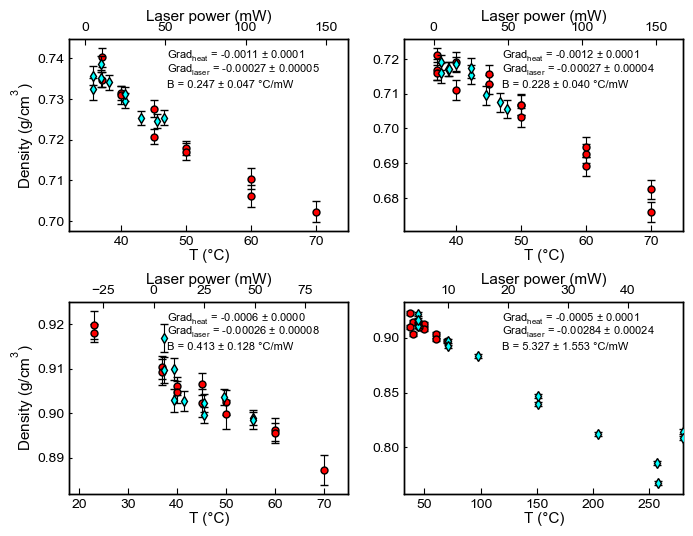

In [50]:

# -----------------------------
# Figure A: 2x2 (max 175 mm wide, pick 150 mm tall)
# -----------------------------
width_mm_A  = 175*1.15
height_mm_A = 150  # safely under 200 mm
figA, axesA = plt.subplots(2, 2, figsize=(mm_to_inches(width_mm_A), mm_to_inches(height_mm_A)),
                           gridspec_kw={'hspace': 0.37, 'wspace': 0.2})
axesA = axesA.flatten()


for j, name in enumerate(sel_A):
    plot_panel(axesA[j], name, is_left=(j % 2 == 0))
plt.tight_layout()
figA.savefig('MainText.png', dpi=300)  # 175 mm wide at 300 dpi when placed at 100%




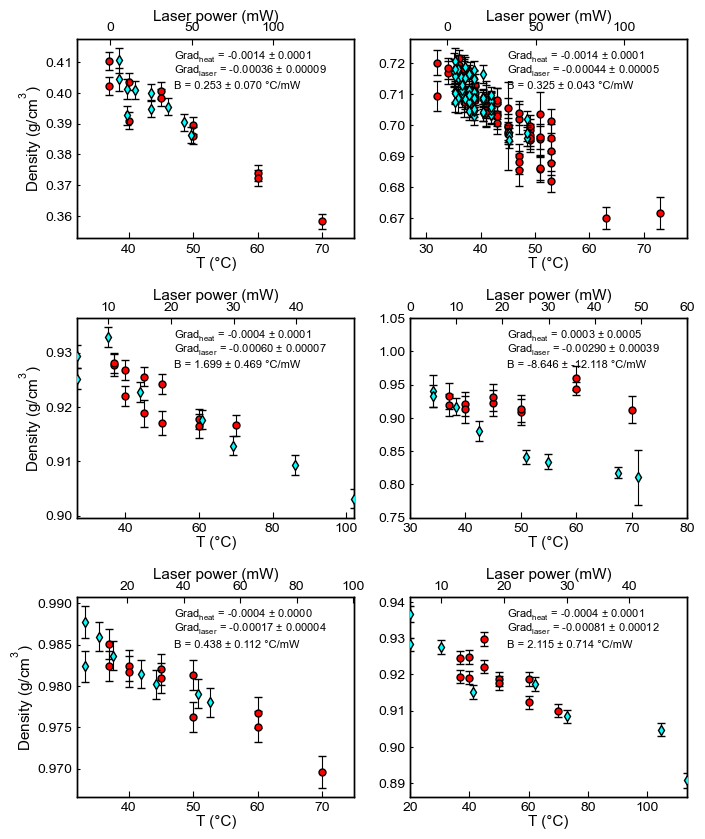

In [62]:
# -----------------------------
# Figure B: 3x2 (max 175 mm wide, pick 190 mm tall)
# -----------------------------
width_mm_B  = 200
height_mm_B = 250  # <= 200 mm
figB, axesB = plt.subplots(3, 2, figsize=(mm_to_inches(width_mm_B), mm_to_inches(height_mm_B)),
                           gridspec_kw={'hspace': 0.4, 'wspace': 0.2})
axesB = axesB.flatten()

for j, name in enumerate(sel_B):
    plot_panel(axesB[j], name, is_left=(j % 2 == 0))

ax = axesB[3]

# set the bottom (temperature) x-limits
ax.set_xlim(30, 80)
ax.set_ylim([ 0.75, 1.05])

# grab its top twin (shares the same y-axis) and set power limits
siblings = list(ax.get_shared_y_axes().get_siblings(ax))
twin_top = next(a for a in siblings if a is not ax)  # or filter by top ticks if needed
# twin_top = next(a for a in siblings if a is not ax and a.xaxis.get_ticks_position()!='bottom')

twin_top.set_xlim(0, 60)

figB.savefig('B_panels_remaining.png', dpi=300)

## Making heating alignement figure

C:\Users\penny\AppData\Local\Temp\ipykernel_3392\3263548300.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


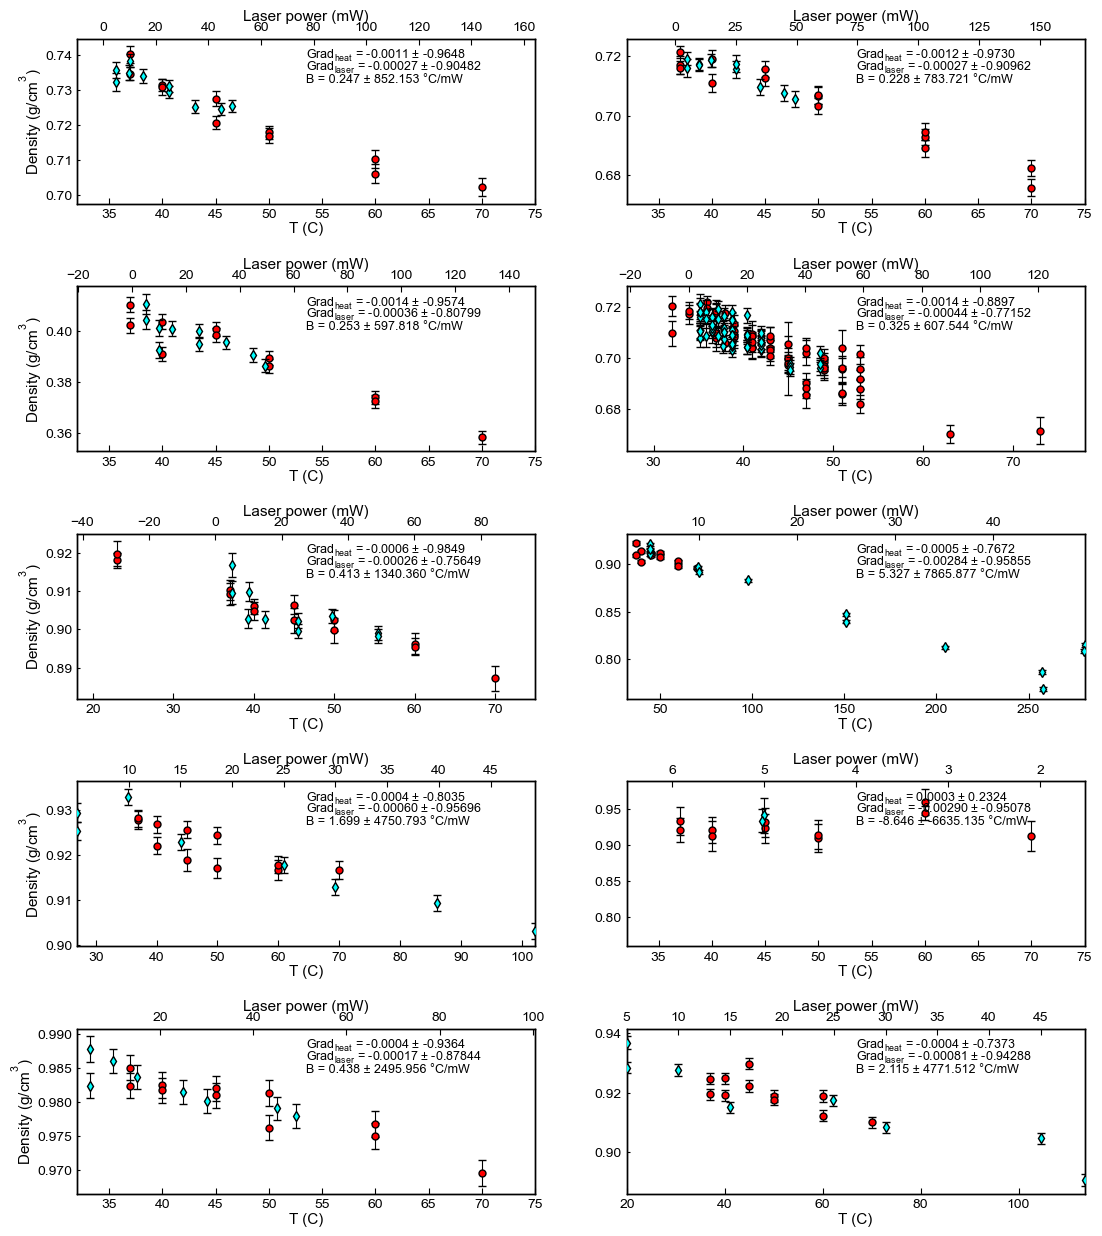

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

series_names = [
    'B30_c1',
    'B23_c3',
    '11i_c2',
    'FG04-13-1',
    '101B',
    '101C',
    'FG04-A3_FI1',
    'FG04-A3_MI1',
    'FG04-A3_FI2',
    'FG04-A3_MI2',
]

fig, axes = plt.subplots(5, 2, figsize=(13, 15), gridspec_kw={'hspace': 0.5})
axes = axes.flatten()

def compute_axes(T_heat, P_power, scale, offset):
    T_min_pad = T_heat.min() - 5
    T_max_pad = T_heat.max() + 5
    T_from_P_min = scale * P_power.min() + offset
    T_from_P_max = scale * P_power.max() + offset
    T_final_min = min(T_min_pad, T_from_P_min)
    T_final_max = max(T_max_pad, T_from_P_max)
    P_final_min = (T_final_min - offset) / scale
    P_final_max = (T_final_max - offset) / scale
    return (T_final_min, T_final_max), (P_final_min, P_final_max)

for i, name in enumerate(series_names):
    ax = axes[i]
    twin_ax = ax.twiny()

    heat = df_heat[df_heat['Series_Name'].str.contains(name)]
    power = df_power[df_power['Series_Name'].str.contains(name)]

    # === Heating data ===
    ax.errorbar(heat['T (C)'], heat['Density g/cm3'],
                yerr=heat['σ Density g/cm3'],
                fmt='o', ecolor='k', elinewidth=0.8,
                mfc='red', ms=5, mec='k', capsize=3)

    # === Power data ===
    twin_ax.errorbar(power['power (mW)'], power['Density g/cm3'],
                     yerr=power['σ Density g/cm3'],
                     fmt='d', ecolor='k', elinewidth=0.8,
                     mfc='cyan', ms=5, mec='k', capsize=3, zorder=100)

    # === Fit heating ===
    x_heat = heat['T (C)']
    y_heat = heat['Density g/cm3']
    slope_h, intercept_h, stderr_h = linregress(x_heat, y_heat)[:3]

    # === Fit power ===
    x_power = power['power (mW)']
    y_power = power['Density g/cm3']
    slope_p, intercept_p, stderr_p = linregress(x_power, y_power)[:3]

    # === Calculate B and error ===
    B = slope_p / slope_h
    B_err = B * np.sqrt((stderr_p / slope_p)**2 + (stderr_h / slope_h)**2)

    # === Align axes ===
    T_equiv = (y_power - intercept_h) / slope_h
    scale_fit, offset_fit = linregress(x_power, T_equiv)[:2]

    (Tmin, Tmax), (Pmin, Pmax) = compute_axes(x_heat, x_power, scale_fit, offset_fit)
    ax.set_xlim(Tmin, Tmax)
    twin_ax.set_xlim(Pmin, Pmax)

    # === Labels ===
    ax.set_xlabel('T (C)')
    if i % 2 == 0:
        ax.set_ylabel('Density (g/cm$^3$)')
    twin_ax.set_xlabel('Laser power (mW)')

    # === Annotations ===
    ax.annotate(f"Grad$_{{heat}}$ = {slope_h:.4f} ± {stderr_h:.4f}",
                xy=(0.5, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9)
    ax.annotate(f"Grad$_{{laser}}$ = {slope_p:.5f} ± {stderr_p:.5f}",
                xy=(0.5, 0.88), xycoords='axes fraction', ha='left', va='top', fontsize=9)
    ax.annotate(f"B = {B:.3f} ± {B_err:.3f} °C/mW",
                xy=(0.5, 0.79), xycoords='axes fraction', ha='left', va='top', fontsize=9)

plt.tight_layout()
fig.savefig('All_B_panels_aligned.png', dpi=300)


NameError: name 'T_heat1' is not defined

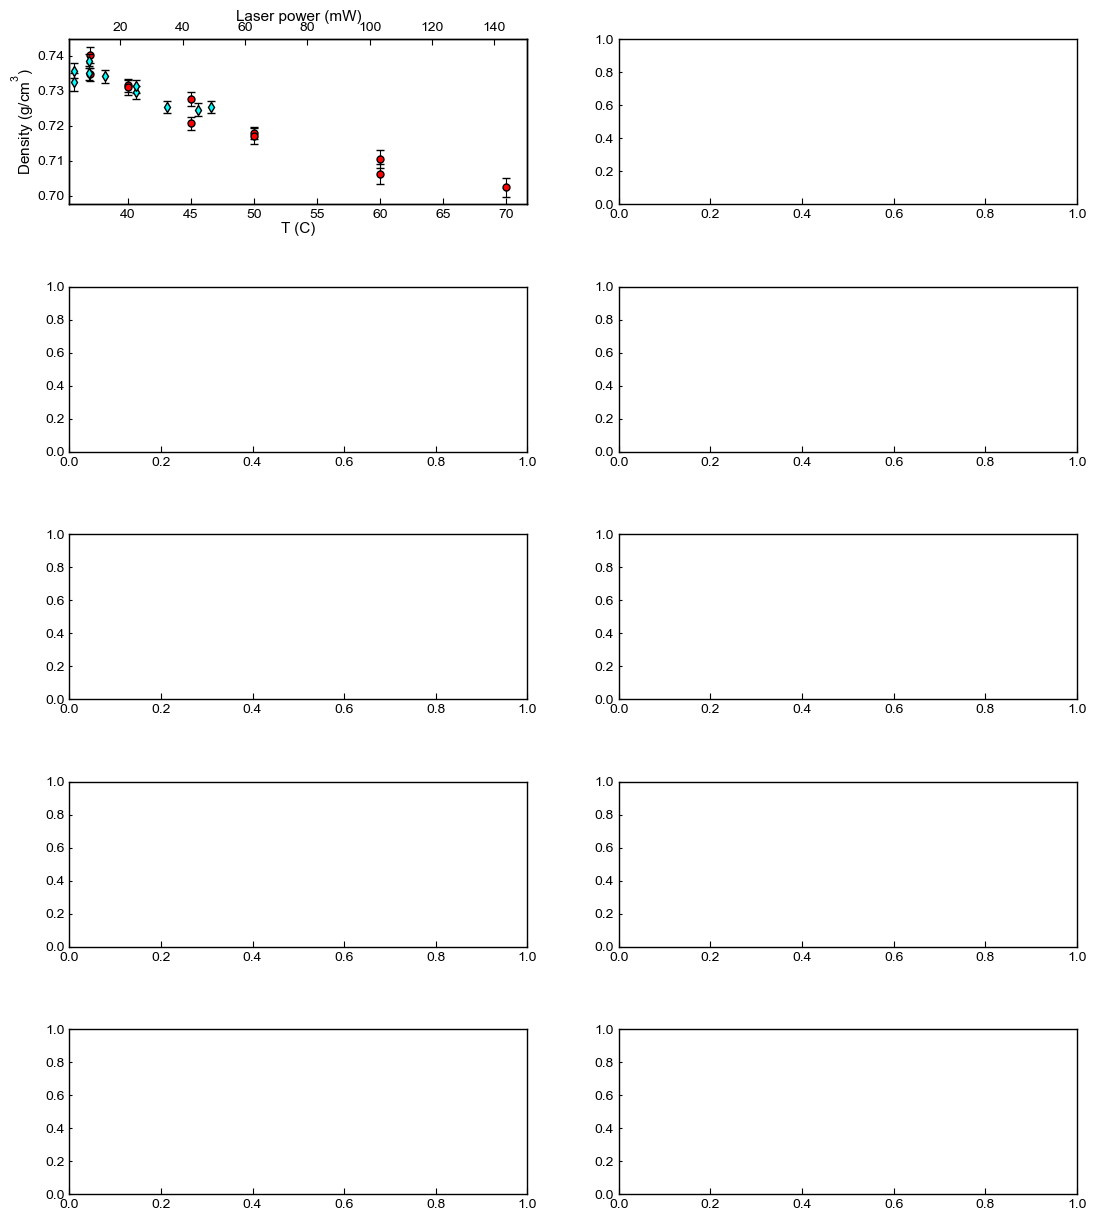

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

series_names = [
    'B30_c1',
    'B23_c3',
    '11i_c2',
    'FG04-13-1',
    '101B',
    '101C',
    'FG04-A3_FI1',
    'FG04-A3_MI1',
    'FG04-A3_FI2',
    'FG04-A3_MI2',
]

fig, axes = plt.subplots(5, 2, figsize=(13, 15), gridspec_kw={'hspace': 0.5})
axes = axes.flatten()

for i, name in enumerate(series_names):
    heat = df_heat[df_heat['Series_Name'].str.contains(name)]
    power = df_power[df_power['Series_Name'].str.contains(name)]
    
    ax_main = axes[i]
    ax_twin = ax_main.twiny()
    
    # === HEATING ===
    ax_main.errorbar(heat['T (C)'], heat['Density g/cm3'],
                     xerr=0, yerr=heat['σ Density g/cm3'],
                     fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

    #ax_main.set_title(name.replace('_power', ''))
    ax_main.set_xlabel('T (C)')
    ax_main.set_ylabel('Density (g/cm$^3$)')

    # === POWER ===
    ax_twin.errorbar(power['power (mW)'], power['Density g/cm3'],
                     xerr=0, yerr=power['σ Density g/cm3'],
                     fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, zorder=100)
    ax_twin.set_xlabel('Laser power (mW)')

    # === FIT HEATING ===
    xh = heat['T (C)']
    yh = heat['Density g/cm3']
    res_h = linregress(xh, yh)
    m_h, b_h, err_h = res_h.slope, res_h.intercept, res_h.stderr

    # === FIT POWER ===
    xp = power['power (mW)']
    yp = power['Density g/cm3']
    res_p = linregress(xp, yp)
    m_p, b_p, err_p = res_p.slope, res_p.intercept, res_p.stderr

    # === B and error ===
    B = m_p / m_h
    B_err = B * np.sqrt((err_p / m_p)**2 + (err_h / m_h)**2)

    # === Align laser x-axis to temperature equivalent ===
    T_equiv = (yp - b_h) / m_h
    m_align, b_align, *_ = linregress(xp, T_equiv)
    Tlim = ax_main.get_xlim()
    ax_twin.set_xlim([(Tlim[0] - b_align) / m_align,
                      (Tlim[1] - b_align) / m_align])
    
    ## other way
    # === Function to compute consistent axis limits ===


    # === Calculate and apply limits ===
    (Tlim1_min, Tlim1_max), (Plim1_min, Plim1_max) = compute_axes(T_heat1, P_power1, scale1, offset1)
    (Tlim2_min, Tlim2_max), (Plim2_min, Plim2_max) = compute_axes(T_heat2, P_power2, scale2, offset2)

    ax1.set_xlim(Tlim1_min, Tlim1_max)
    ax2.set_xlim(Tlim2_min, Tlim2_max)
    ax4.set_xlim(Plim1_min, Plim1_max)
    ax3.set_xlim(Plim2_min, Plim2_max)

    # === Annotations ===
    ax_twin.annotate(f"Grad$_{{heat}}$ = {m_h:.4f} ± {err_h:.4f}\n"
                     f"Grad$_{{laser}}$ = {m_p:.5f} ± {err_p:.5f}\n"
                     f"B = {B:.3f} ± {B_err:.3f} °C/mW",
                     xy=(0.4, 0.88), xycoords='axes fraction',
                     ha='left', va='top', fontsize=10)

plt.tight_layout()
fig.savefig('All_Temp_Laser_10panel.png', dpi=300)


## Supporting info- looping through all the laser power series that also have heating series

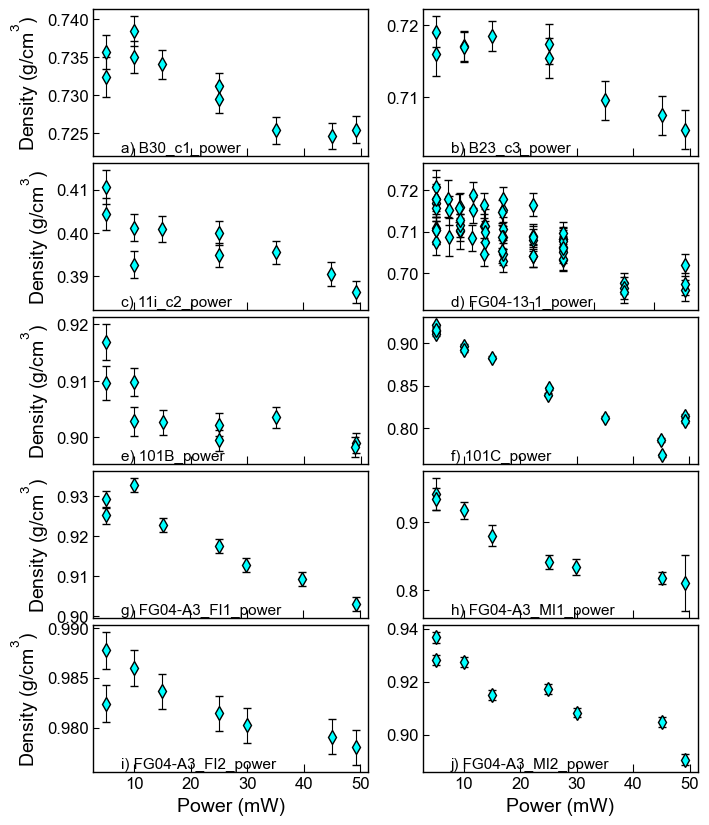

In [ ]:
import string
labels_annotated = [f"{letter}) {label}" for letter, label in zip(string.ascii_lowercase, labels_power)]

# Assume merged_power_df exists from earlier
# e.g., with columns like 'Power (mW)', 'Density (g/cm³)', 'Series_Name'

# Create subplots: 5 rows x 2 columns for 10 plots
fig, axes = plt.subplots(5, 2, figsize=(6.5*1.2, 9*1.1))
axes = axes.flatten()

# Loop over each group and plot
for ax, label, label_name in zip(axes, labels_annotated, labels_power):
    subset = df_power[df_power['Series_Name'] == label_name]

    
    # Scatter plot: adjust if you want error bars etc.
    ax.errorbar(subset['power (mW)'], subset['Density g/cm3'],
             xerr=0, yerr=subset['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8,
             mfc='cyan', ms=7, mec='k', capsize=3,
             label='Laser power')
    
    # Annotate with panel label
    ax.annotate(label, xy=(0.1, 0.1), xycoords='axes fraction', fontsize=11, va='top')
    
    # Label axes



for i, ax in enumerate(axes):
    # Only label x-axis for bottom row (last 2 plots: index 8 and 9)
    if i in [8, 9]:
        ax.set_xlabel('Power (mW)')
    else:
        ax.set_xticklabels([])


    if i % 2 == 0:
        ax.set_ylabel('Density (g/cm$^{3}$)')

plt.subplots_adjust(hspace=0.05) 
#plt.tight_layout()
plt.show()
fig.savefig('Supplement_power_series_with_heating_series.png', dpi=300)

## Same for temperature

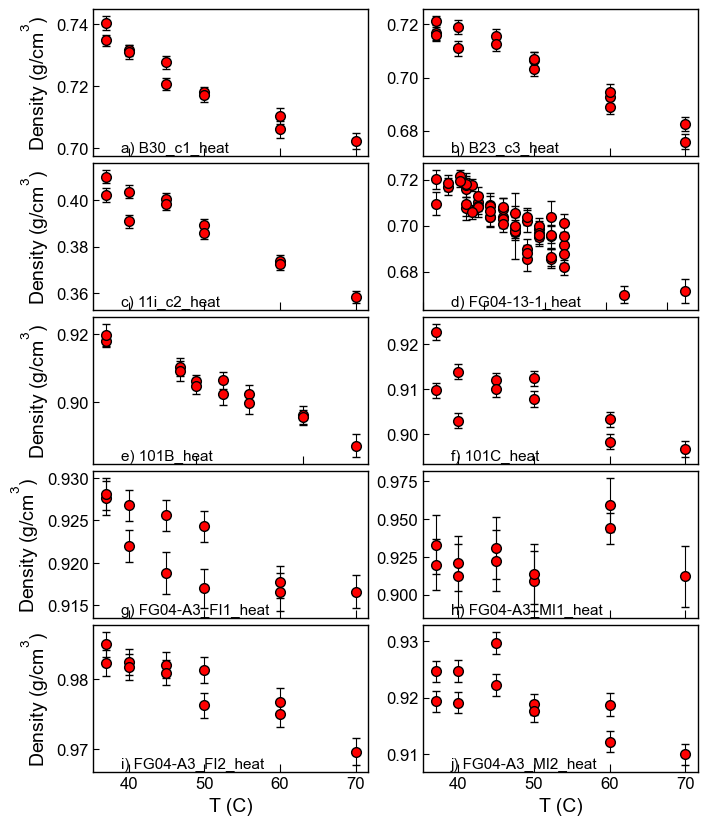

In [ ]:
import string
labels_annotated = [f"{letter}) {label}" for letter, label in zip(string.ascii_lowercase, labels_heat)]

# Assume merged_power_df exists from earlier
# e.g., with columns like 'T (C)', 'Density (g/cm³)', 'Series_Name'

# Create subplots: 5 rows x 2 columns for 10 plots
fig, axes = plt.subplots(5, 2, figsize=(6.5*1.2, 9*1.1))
axes = axes.flatten()

# Loop over each group and plot
for ax, label, label_name in zip(axes, labels_annotated, labels_heat):
    subset = df_heat[df_heat['Series_Name'] == label_name]

    
    # Scatter plot: adjust if you want error bars etc.
    ax.errorbar(subset['T (C)'], subset['Density g/cm3'],
             xerr=0, yerr=subset['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8,
             mfc='red', ms=7, mec='k', capsize=3,
             label='Laser power')
    
    # Annotate with panel label
    ax.annotate(label, xy=(0.1, 0.1), xycoords='axes fraction', fontsize=11, va='top')
    
    # Label axes



for i, ax in enumerate(axes):
    # Only label x-axis for bottom row (last 2 plots: index 8 and 9)
    if i in [8, 9]:
        ax.set_xlabel('T (C)')
    else:
        ax.set_xticklabels([])


    if i % 2 == 0:
        ax.set_ylabel('Density (g/cm$^{3}$)')

plt.subplots_adjust(hspace=0.05) 
#plt.tight_layout()
plt.show()
fig.savefig('Supplement_heat_series_with_heating_series.png', dpi=300)

## B values for B30 and B23

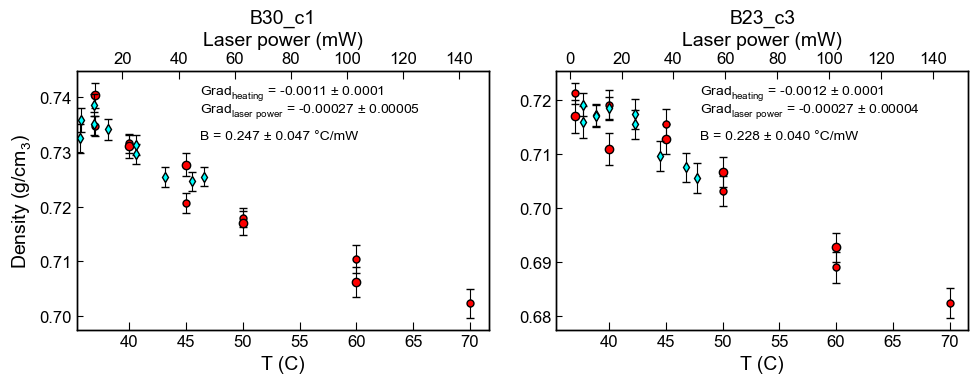

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define masks
B30 = df_I['filename'].str.contains('B30_c1')
down = df_I['filename'].str.contains('down')
B23 = df_I['filename'].str.contains('B23_c3') & ~(df_I['filename'].str.contains('lid'))
B23_lid = df_I['filename'].str.contains('B23_c3') & df_I['filename'].str.contains('lid')
power_c1 = df_I['filename'].str.contains('B30_c1') & df_I['filename'].str.contains('mW')
power_c3 = df_I['filename'].str.contains('B23_c3') & df_I['filename'].str.contains('mW')

# === PLOT B30_c1 ===
ax1.errorbar(df_I['T (C)'].loc[B30], df_I['Density g/cm3'].loc[B30],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[B30],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.plot(df_I['T (C)'].loc[down & B30], df_I['Density g/cm3'].loc[down & B30],
         'ok', mfc='red', zorder=100)
ax1.set_title('B30_c1')

# === PLOT B23_c3 ===
ax2.errorbar(df_I['T (C)'].loc[B23], df_I['Density g/cm3'].loc[B23],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[B23],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')

ax2.plot(df_I['T (C)'].loc[down & B23], df_I['Density g/cm3'].loc[down & B23],
         'ok', mfc='red', zorder=100, label='heat: down')

ax2.plot(df_I['T (C)'].loc[down & B23_lid], df_I['Density g/cm3'].loc[down & B23_lid],
         'ok', mfc='red', zorder=100, label='heat: down')

# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax3.errorbar(df_I['power (mW)'].loc[power_c3], df_I['Density g/cm3'].loc[power_c3],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[power_c3],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power')

ax4.errorbar(df_I['power (mW)'].loc[power_c1], df_I['Density g/cm3'].loc[power_c1],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[power_c1],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power')

# === FIT LINES AND ERRORS ===
# Heating - B30_c1
mask_heat_c1 = B30 & ~(df_I['filename'].str.contains('mW'))
x_c1 = df_I['T (C)'].loc[mask_heat_c1]
y_c1 = df_I['Density g/cm3'].loc[mask_heat_c1]
res_c1 = linregress(x_c1, y_c1)
slope_c1, intercept_c1, stderr_c1 = res_c1.slope, res_c1.intercept, res_c1.stderr

# Heating - B23_c3
mask_heat_c3 = df_I['filename'].str.contains('B23_c3') & ~(df_I['filename'].str.contains('mW'))
x_c3 = df_I['T (C)'].loc[mask_heat_c3]
y_c3 = df_I['Density g/cm3'].loc[mask_heat_c3]
res_c3 = linregress(x_c3, y_c3)
slope_c3, intercept_c3, stderr_c3 = res_c3.slope, res_c3.intercept, res_c3.stderr

# Laser - B30_c1
x_power_c1 = df_I['power (mW)'].loc[power_c1]
y_power_c1 = df_I['Density g/cm3'].loc[power_c1]
res_power_c1 = linregress(x_power_c1, y_power_c1)
slope_power_c1, intercept_power_c1, stderr_power_c1 = res_power_c1.slope, res_power_c1.intercept, res_power_c1.stderr

# Laser - B23_c3
x_power_c3 = df_I['power (mW)'].loc[power_c3]
y_power_c3 = df_I['Density g/cm3'].loc[power_c3]
res_power_c3 = linregress(x_power_c3, y_power_c3)
slope_power_c3, intercept_power_c3, stderr_power_c3 = res_power_c3.slope, res_power_c3.intercept, res_power_c3.stderr

# === B and propagated error ===
B_c1 = slope_power_c1 / slope_c1
B_err_c1 = B_c1 * np.sqrt((stderr_power_c1 / slope_power_c1)**2 + (stderr_c1 / slope_c1)**2)

B_c3 = slope_power_c3 / slope_c3
B_err_c3 = B_c3 * np.sqrt((stderr_power_c3 / slope_power_c3)**2 + (stderr_c3 / slope_c3)**2)

# === ALIGN LASER AXIS ===
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)

Tlim1 = ax1.get_xlim()
Tlim2 = ax2.get_xlim()

ax4.set_xlim([(Tlim1[0] - offset_fit_c1) / scale_fit_c1, 
              (Tlim1[1] - offset_fit_c1) / scale_fit_c1])

ax3.set_xlim([(Tlim2[0] - offset_fit_c3) / scale_fit_c3, 
              (Tlim2[1] - offset_fit_c3) / scale_fit_c3])

# === FINAL LABELS ===
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('Density (g/cm$_3$)')
ax1.set_title('B30_c1')
ax2.set_title('B23_c3')

# Annotations for B30_c1
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} ± {stderr_c1:.4f}",
             xy=(0.3, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.5f} ± {stderr_power_c1:.5f}",
             xy=(0.3, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"B = {B_c1:.3f} ± {B_err_c1:.3f} °C/mW",
             xy=(0.3, 0.77), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

# Annotations for B23_c3
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} ± {stderr_c3:.4f}",
             xy=(0.35, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.5f} ± {stderr_power_c3:.5f}",
             xy=(0.35, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"B = {B_c3:.3f} ± {B_err_c3:.3f} °C/mW",
             xy=(0.35, 0.77), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

plt.tight_layout()
fig.savefig('TestTemp_Bs.png', dpi=300)


## Same for HB diad ratio

In [ ]:
df_I['HB_diad']=calculate_HB_area(df_I)

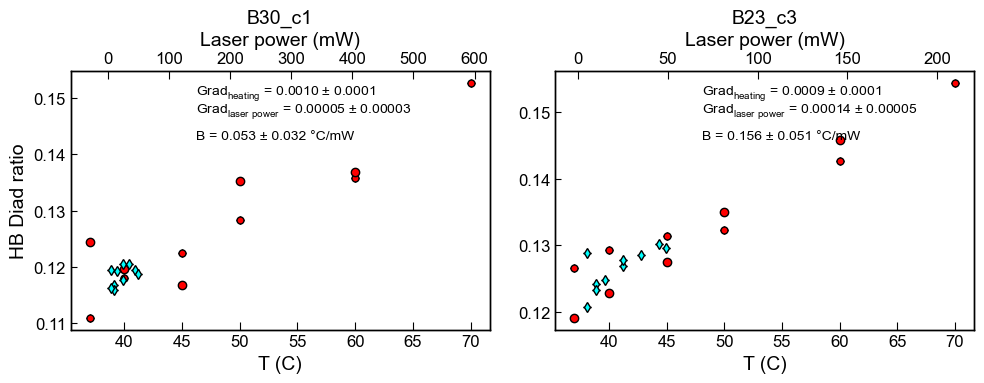

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define masks


# === PLOT B30_c1 ===
ax1.errorbar(df_I['T (C)'].loc[B30], df_I['HB_diad'].loc[B30],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[B30]*0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.plot(df_I['T (C)'].loc[down & B30], df_I['HB_diad'].loc[down & B30],
         'ok', mfc='red', zorder=100)
ax1.set_title('B30_c1')

# === PLOT B23_c3 ===
ax2.errorbar(df_I['T (C)'].loc[B23], df_I['HB_diad'].loc[B23],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[B23]*0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')

ax2.plot(df_I['T (C)'].loc[down & B23], df_I['HB_diad'].loc[down & B23],
         'ok', mfc='red', zorder=100, label='heat: down')

ax2.plot(df_I['T (C)'].loc[down & B23_lid], df_I['HB_diad'].loc[down & B23_lid],
         'ok', mfc='red', zorder=100, label='heat: down')

# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax3.errorbar(df_I['power (mW)'].loc[power_c3], df_I['HB_diad'].loc[power_c3],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[power_c3]*0,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power')

ax4.errorbar(df_I['power (mW)'].loc[power_c1], df_I['HB_diad'].loc[power_c1],
             xerr=0, yerr=df_I['σ Density g/cm3'].loc[power_c1]*0,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power')

# === FIT LINES AND ERRORS ===
# Heating - B30_c1
mask_heat_c1 = B30 & ~(df_I['filename'].str.contains('mW'))
x_c1 = df_I['T (C)'].loc[mask_heat_c1]
y_c1 = df_I['HB_diad'].loc[mask_heat_c1]
res_c1 = linregress(x_c1, y_c1)
slope_c1, intercept_c1, stderr_c1 = res_c1.slope, res_c1.intercept, res_c1.stderr

# Heating - B23_c3
mask_heat_c3 = df_I['filename'].str.contains('B23_c3') & ~(df_I['filename'].str.contains('mW'))
x_c3 = df_I['T (C)'].loc[mask_heat_c3]
y_c3 = df_I['HB_diad'].loc[mask_heat_c3]
res_c3 = linregress(x_c3, y_c3)
slope_c3, intercept_c3, stderr_c3 = res_c3.slope, res_c3.intercept, res_c3.stderr

# Laser - B30_c1
x_power_c1 = df_I['power (mW)'].loc[power_c1]
y_power_c1 = df_I['HB_diad'].loc[power_c1]
res_power_c1 = linregress(x_power_c1, y_power_c1)
slope_power_c1, intercept_power_c1, stderr_power_c1 = res_power_c1.slope, res_power_c1.intercept, res_power_c1.stderr

# Laser - B23_c3
x_power_c3 = df_I['power (mW)'].loc[power_c3]
y_power_c3 = df_I['HB_diad'].loc[power_c3]
res_power_c3 = linregress(x_power_c3, y_power_c3)
slope_power_c3, intercept_power_c3, stderr_power_c3 = res_power_c3.slope, res_power_c3.intercept, res_power_c3.stderr

# === B and propagated error ===
B_c1 = slope_power_c1 / slope_c1
B_err_c1 = B_c1 * np.sqrt((stderr_power_c1 / slope_power_c1)**2 + (stderr_c1 / slope_c1)**2)

B_c3 = slope_power_c3 / slope_c3
B_err_c3 = B_c3 * np.sqrt((stderr_power_c3 / slope_power_c3)**2 + (stderr_c3 / slope_c3)**2)

# === ALIGN LASER AXIS ===
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)

Tlim1 = ax1.get_xlim()
Tlim2 = ax2.get_xlim()

ax4.set_xlim([(Tlim1[0] - offset_fit_c1) / scale_fit_c1, 
              (Tlim1[1] - offset_fit_c1) / scale_fit_c1])

ax3.set_xlim([(Tlim2[0] - offset_fit_c3) / scale_fit_c3, 
              (Tlim2[1] - offset_fit_c3) / scale_fit_c3])

# === FINAL LABELS ===
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('HB Diad ratio')
ax1.set_title('B30_c1')
ax2.set_title('B23_c3')

# Annotations for B30_c1
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} ± {stderr_c1:.4f}",
             xy=(0.3, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.5f} ± {stderr_power_c1:.5f}",
             xy=(0.3, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"B = {B_c1:.3f} ± {B_err_c1:.3f} °C/mW",
             xy=(0.3, 0.77), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

# Annotations for B23_c3
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} ± {stderr_c3:.4f}",
             xy=(0.35, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.5f} ± {stderr_power_c3:.5f}",
             xy=(0.35, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"B = {B_c3:.3f} ± {B_err_c3:.3f} °C/mW",
             xy=(0.35, 0.77), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

plt.tight_layout()
fig.savefig('TestTemp_Bs.png', dpi=300)


## 11 C2 and FGO4-13

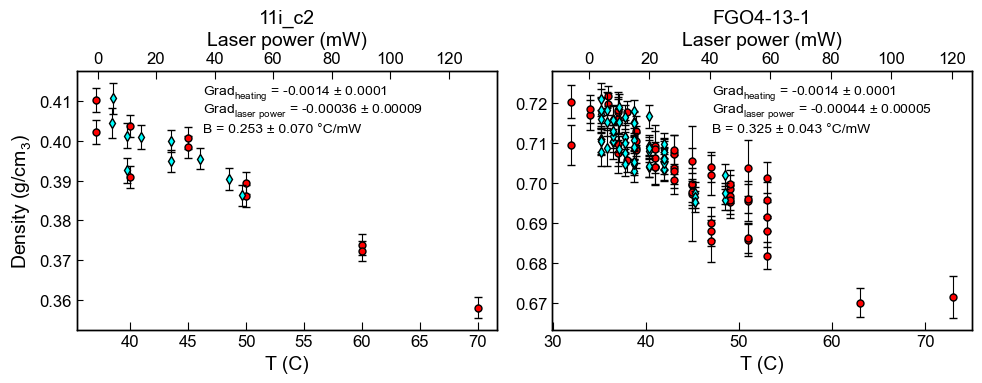

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define masks

# === TEMP SERIES ===
ax1.errorbar(df_IS_heat['T (C)'], df_IS_heat['Density g/cm3'],
             xerr=0, yerr=df_IS_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_title('11i_c2')

# === second series ===
ax2.set_title('FGO4-13-1')
ax2.errorbar(df_a13_heat['T (C)'], df_a13_heat['Density g/cm3'],
             xerr=0, yerr=df_a13_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')



# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax4.errorbar(df_IS_power_c2['power (mW)'], df_IS_power_c2['Density g/cm3'],
             xerr=0, yerr=df_IS_power_c2['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

ax3.errorbar(df_a13_power['power (mW)'], df_a13_power['Density g/cm3'],
             xerr=0, yerr=df_a13_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

# === FIT LINES AND ERRORS ===
# Heating - B30_c1

x_c1 = df_IS_heat['T (C)']
y_c1 = df_IS_heat['Density g/cm3']
res_c1 = linregress(x_c1, y_c1)
slope_c1, intercept_c1, stderr_c1 = res_c1.slope, res_c1.intercept, res_c1.stderr


# Laser - B30_c1
x_power_c1 = df_IS_power_c2['power (mW)']
y_power_c1 = df_IS_power_c2['Density g/cm3']
res_power_c1 = linregress(x_power_c1, y_power_c1)
slope_power_c1, intercept_power_c1, stderr_power_c1 = res_power_c1.slope, res_power_c1.intercept, res_power_c1.stderr


# # Heating - B23_c3
x_c3 = df_a13_heat['T (C)']
y_c3 = df_a13_heat['Density g/cm3']
res_c3 = linregress(x_c3, y_c3)
slope_c3, intercept_c3, stderr_c3 = res_c3.slope, res_c3.intercept, res_c3.stderr


# Laser - B23_c3
x_power_c3 = df_a13_power['power (mW)']
y_power_c3 = df_a13_power['Density g/cm3']
res_power_c3 = linregress(x_power_c3, y_power_c3)
slope_power_c3, intercept_power_c3, stderr_power_c3 = res_power_c3.slope, res_power_c3.intercept, res_power_c3.stderr

# === B and propagated error ===
B_c1 = slope_power_c1 / slope_c1
B_err_c1 = B_c1 * np.sqrt((stderr_power_c1 / slope_power_c1)**2 + (stderr_c1 / slope_c1)**2)

B_c3 = slope_power_c3 / slope_c3
B_err_c3 = B_c3 * np.sqrt((stderr_power_c3 / slope_power_c3)**2 + (stderr_c3 / slope_c3)**2)

# === ALIGN LASER AXIS ===
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)

Tlim1 = ax1.get_xlim()
Tlim2 = ax2.get_xlim()



ax3.set_xlim([(Tlim2[0] - offset_fit_c3) / scale_fit_c3, 
              (Tlim2[1] - offset_fit_c3) / scale_fit_c3])

ax4.set_xlim([(Tlim1[0] - offset_fit_c1) / scale_fit_c1, 
              (Tlim1[1] - offset_fit_c1) / scale_fit_c1])

# === FINAL LABELS ===
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('Density (g/cm$_3$)')


# Annotations for B30_c1
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} ± {stderr_c1:.4f}",
             xy=(0.3, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.5f} ± {stderr_power_c1:.5f}",
             xy=(0.3, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"B = {B_c1:.3f} ± {B_err_c1:.3f} °C/mW",
             xy=(0.3, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

# Annotations for B23_c3
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} ± {stderr_c3:.4f}",
             xy=(0.38, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.5f} ± {stderr_power_c3:.5f}",
             xy=(0.38, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"B = {B_c3:.3f} ± {B_err_c3:.3f} °C/mW",
             xy=(0.38, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

plt.tight_layout()
fig.savefig('TestTemp_I_Fogo.png', dpi=300)


## Two Fogo ones in the same crystal 101B and 101C

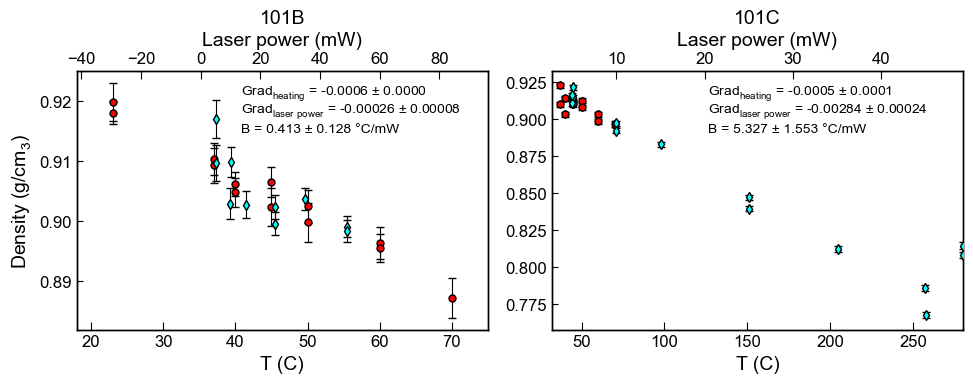

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define masks

# === TEMP SERIES ===
ax1.errorbar(df_101B_heat['T (C)'], df_101B_heat['Density g/cm3'],
             xerr=0, yerr=df_101B_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_title('101B')

# === second series ===
ax2.set_title('101C')
ax2.errorbar(df_101C_heat['T (C)'], df_101C_heat['Density g/cm3'],
             xerr=0, yerr=df_101C_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')



# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax4.errorbar(df_101B_power['power (mW)'], df_101B_power['Density g/cm3'],
             xerr=0, yerr=df_101B_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

ax3.errorbar(df_101C_power['power (mW)'], df_101C_power['Density g/cm3'],
             xerr=0, yerr=df_101C_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

# === FIT LINES AND ERRORS ===
# Heating - B30_c1

x_c1 = df_101B_heat['T (C)']
y_c1 = df_101B_heat['Density g/cm3']
res_c1 = linregress(x_c1, y_c1)
slope_c1, intercept_c1, stderr_c1 = res_c1.slope, res_c1.intercept, res_c1.stderr


# Laser - B30_c1
x_power_c1 = df_101B_power['power (mW)']
y_power_c1 = df_101B_power['Density g/cm3']
res_power_c1 = linregress(x_power_c1, y_power_c1)
slope_power_c1, intercept_power_c1, stderr_power_c1 = res_power_c1.slope, res_power_c1.intercept, res_power_c1.stderr


# # Heating - B23_c3
x_c3 = df_101C_heat['T (C)']
y_c3 = df_101C_heat['Density g/cm3']
res_c3 = linregress(x_c3, y_c3)
slope_c3, intercept_c3, stderr_c3 = res_c3.slope, res_c3.intercept, res_c3.stderr


# Laser - B23_c3
x_power_c3 = df_101C_power['power (mW)']
y_power_c3 = df_101C_power['Density g/cm3']
res_power_c3 = linregress(x_power_c3, y_power_c3)
slope_power_c3, intercept_power_c3, stderr_power_c3 = res_power_c3.slope, res_power_c3.intercept, res_power_c3.stderr

# === B and propagated error ===
B_c1 = slope_power_c1 / slope_c1
B_err_c1 = B_c1 * np.sqrt((stderr_power_c1 / slope_power_c1)**2 + (stderr_c1 / slope_c1)**2)

B_c3 = slope_power_c3 / slope_c3
B_err_c3 = B_c3 * np.sqrt((stderr_power_c3 / slope_power_c3)**2 + (stderr_c3 / slope_c3)**2)

# === ALIGN LASER AXIS ===
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)


##  Align X axis to give right gradients ################
######################################################333

# --- Define data and fit params for 101B ---
T_heat1 = df_101B_heat['T (C)']
P_power1 = df_101B_power['power (mW)']
scale1, offset1 = scale_fit_c1, offset_fit_c1

# --- Define data and fit params for FGO4 ---
T_heat2 =  df_101C_heat['T (C)']
P_power2 =  df_101C_power['power (mW)']
scale2, offset2 = scale_fit_c3, offset_fit_c3

# === Function to compute consistent axis limits ===
def compute_axes(T_heat, P_power, scale, offset):
    # Pad temperature range
    T_min_pad = T_heat.min() - 5
    T_max_pad = T_heat.max() + 5

    # Get equivalent T from full laser power range
    T_from_P_min = scale * P_power.min() + offset
    T_from_P_max = scale * P_power.max() + offset

    # Use the full extent needed for T axis
    T_final_min = min(T_min_pad, T_from_P_min)
    T_final_max = max(T_max_pad, T_from_P_max)

    # Back-calculate power axis limits from final T range
    P_final_min = (T_final_min - offset) / scale
    P_final_max = (T_final_max - offset) / scale

    return (T_final_min, T_final_max), (P_final_min, P_final_max)

# === Calculate and apply limits ===
(Tlim1_min, Tlim1_max), (Plim1_min, Plim1_max) = compute_axes(T_heat1, P_power1, scale1, offset1)
(Tlim2_min, Tlim2_max), (Plim2_min, Plim2_max) = compute_axes(T_heat2, P_power2, scale2, offset2)

ax1.set_xlim(Tlim1_min, Tlim1_max)
ax2.set_xlim(Tlim2_min, Tlim2_max)
ax4.set_xlim(Plim1_min, Plim1_max)
ax3.set_xlim(Plim2_min, Plim2_max)



# === FINAL LABELS ===
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('Density (g/cm$_3$)')



# Annotations for B30_c1
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} ± {stderr_c1:.4f}",
             xy=(0.4, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.5f} ± {stderr_power_c1:.5f}",
             xy=(0.4, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"B = {B_c1:.3f} ± {B_err_c1:.3f} °C/mW",
             xy=(0.4, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

# Annotations for B23_c3
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} ± {stderr_c3:.4f}",
             xy=(0.38, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.5f} ± {stderr_power_c3:.5f}",
             xy=(0.38, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"B = {B_c3:.3f} ± {B_err_c3:.3f} °C/mW",
             xy=(0.38, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

plt.tight_layout()
fig.savefig('TestTemp_101C_101B.png', dpi=300)


## Fogo FI one vs. Fogo MI

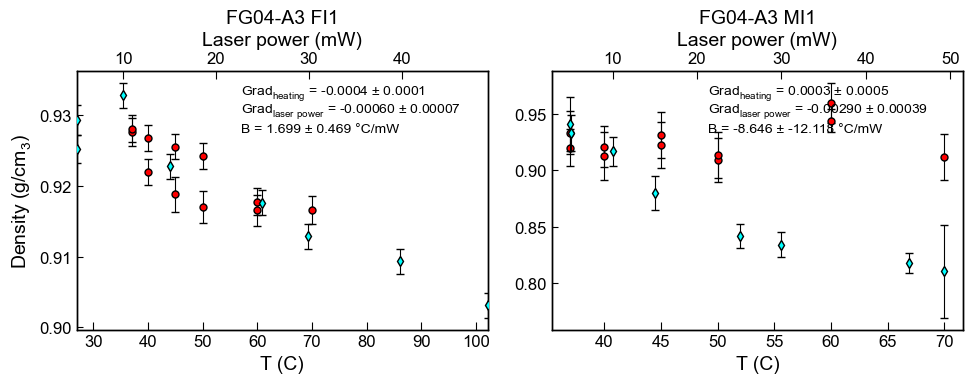

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define masks

# === TEMP SERIES ===
ax1.errorbar(df_Fogo_FI_heat['T (C)'], df_Fogo_FI_heat['Density g/cm3'],
             xerr=0, yerr=df_Fogo_FI_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_title('FG04-A3 FI1')

# === second series ===
ax2.set_title('FG04-A3 MI1')
ax2.errorbar(df_Fogo_MI_heat['T (C)'], df_Fogo_MI_heat['Density g/cm3'],
             xerr=0, yerr=df_Fogo_MI_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')



# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax4.errorbar(df_Fogo_FI_power['power (mW)'], df_Fogo_FI_power['Density g/cm3'],
             xerr=0, yerr=df_Fogo_FI_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

ax3.errorbar(df_Fogo_MI_power['power (mW)'], df_Fogo_MI_power['Density g/cm3'],
             xerr=0, yerr=df_Fogo_MI_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

# === FIT LINES AND ERRORS ===
# Heating - B30_c1

x_c1 = df_Fogo_FI_heat['T (C)']
y_c1 = df_Fogo_FI_heat['Density g/cm3']
res_c1 = linregress(x_c1, y_c1)
slope_c1, intercept_c1, stderr_c1 = res_c1.slope, res_c1.intercept, res_c1.stderr


# Laser - B30_c1
x_power_c1 = df_Fogo_FI_power['power (mW)']
y_power_c1 = df_Fogo_FI_power['Density g/cm3']
res_power_c1 = linregress(x_power_c1, y_power_c1)
slope_power_c1, intercept_power_c1, stderr_power_c1 = res_power_c1.slope, res_power_c1.intercept, res_power_c1.stderr


# # Heating - B23_c3
x_c3 = df_Fogo_MI_heat['T (C)']
y_c3 = df_Fogo_MI_heat['Density g/cm3']
res_c3 = linregress(x_c3, y_c3)
slope_c3, intercept_c3, stderr_c3 = res_c3.slope, res_c3.intercept, res_c3.stderr


# Laser - B23_c3
x_power_c3 = df_Fogo_MI_power['power (mW)']
y_power_c3 = df_Fogo_MI_power['Density g/cm3']
res_power_c3 = linregress(x_power_c3, y_power_c3)
slope_power_c3, intercept_power_c3, stderr_power_c3 = res_power_c3.slope, res_power_c3.intercept, res_power_c3.stderr

# === B and propagated error ===
B_c1 = slope_power_c1 / slope_c1
B_err_c1 = B_c1 * np.sqrt((stderr_power_c1 / slope_power_c1)**2 + (stderr_c1 / slope_c1)**2)

B_c3 = slope_power_c3 / slope_c3
B_err_c3 = B_c3 * np.sqrt((stderr_power_c3 / slope_power_c3)**2 + (stderr_c3 / slope_c3)**2)

# === ALIGN LASER AXIS ===
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)


##  Align X axis to give right gradients ################
######################################################333

# --- Define data and fit params for 101B ---
T_heat1 = df_Fogo_FI_heat['T (C)']
P_power1 = df_Fogo_FI_power['power (mW)']
scale1, offset1 = scale_fit_c1, offset_fit_c1

# --- Define data and fit params for FGO4 ---
T_heat2 = df_Fogo_MI_heat['T (C)']
P_power2 = df_Fogo_MI_power['power (mW)']
scale2, offset2 = scale_fit_c3, offset_fit_c3

# === Function to compute consistent axis limits ===
def compute_axes(T_heat, P_power, scale, offset):
    # Pad temperature range
    T_min_pad = T_heat.min() - 5
    T_max_pad = T_heat.max() + 5

    # Get equivalent T from full laser power range
    T_from_P_min = scale * P_power.min() + offset
    T_from_P_max = scale * P_power.max() + offset

    # Use the full extent needed for T axis
    T_final_min = min(T_min_pad, T_from_P_min)
    T_final_max = max(T_max_pad, T_from_P_max)

    # Back-calculate power axis limits from final T range
    P_final_min = (T_final_min - offset) / scale
    P_final_max = (T_final_max - offset) / scale

    return (T_final_min, T_final_max), (P_final_min, P_final_max)

# === Calculate and apply limits ===
(Tlim1_min, Tlim1_max), (Plim1_min, Plim1_max) = compute_axes(T_heat1, P_power1, scale1, offset1)
(Tlim2_min, Tlim2_max), (Plim2_min, Plim2_max) = compute_axes(T_heat2, P_power2, scale2, offset2)

ax1.set_xlim(Tlim1_min, Tlim1_max)
#ax2.set_xlim(Tlim2_min, Tlim2_max)
ax4.set_xlim(Plim1_min, Plim1_max)
#ax3.set_xlim(Plim2_min, Plim2_max)



# === FINAL LABELS ===
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('Density (g/cm$_3$)')



# Annotations for B30_c1
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} ± {stderr_c1:.4f}",
             xy=(0.4, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.5f} ± {stderr_power_c1:.5f}",
             xy=(0.4, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"B = {B_c1:.3f} ± {B_err_c1:.3f} °C/mW",
             xy=(0.4, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

# Annotations for B23_c3
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} ± {stderr_c3:.4f}",
             xy=(0.38, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.5f} ± {stderr_power_c3:.5f}",
             xy=(0.38, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"B = {B_c3:.3f} ± {B_err_c3:.3f} °C/mW",
             xy=(0.38, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

plt.tight_layout()
fig.savefig('TestTemp_FI_MIreg1.png', dpi=300)


## Same but for HB/Diad ratios

In [ ]:



df_Fogo_FI_heat['HB_diad']=calculate_HB_area(df_Fogo_FI_heat)
df_Fogo_MI_heat['HB_diad']=calculate_HB_area(df_Fogo_MI_heat)
df_Fogo_FI_power['HB_diad'] =calculate_HB_area(df_Fogo_FI_power)
df_Fogo_MI_power['HB_diad']=calculate_HB_area(df_Fogo_MI_power)


df_101B_heat['HB_diad']=calculate_HB_area(df_101B_heat)
df_101C_heat['HB_diad']=calculate_HB_area(df_101C_heat)

C:\Users\penny\AppData\Local\Temp\ipykernel_19068\3358730338.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Fogo_FI_heat['HB_diad']=calculate_HB_area(df_Fogo_FI_heat)
C:\Users\penny\AppData\Local\Temp\ipykernel_19068\3358730338.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Fogo_MI_heat['HB_diad']=calculate_HB_area(df_Fogo_MI_heat)
C:\Users\penny\AppData\Local\Temp\ipykernel_19068\3358730338.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

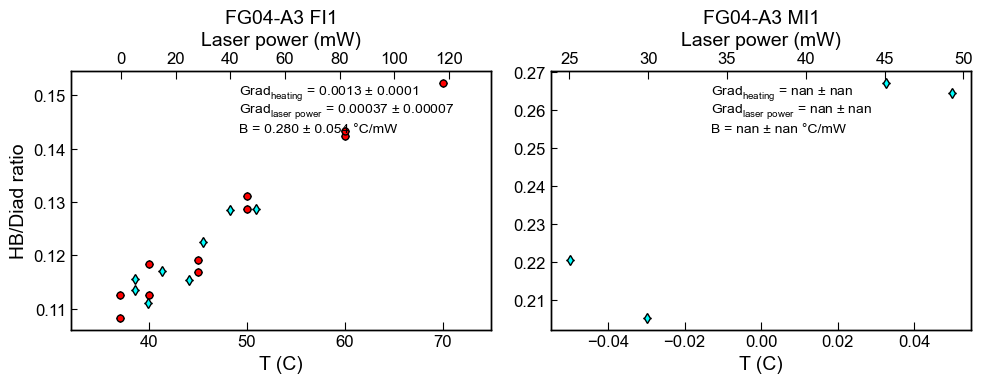

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define masks

# === TEMP SERIES ===
ax1.errorbar(df_Fogo_FI_heat['T (C)'], df_Fogo_FI_heat['HB_diad'],
             xerr=0, yerr=df_Fogo_FI_heat['σ Density g/cm3']*0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_title('FG04-A3 FI1')

# === second series ===
ax2.set_title('FG04-A3 MI1')
ax2.errorbar(df_Fogo_MI_heat['T (C)'], df_Fogo_MI_heat['HB_diad'],
             xerr=0, yerr=df_Fogo_MI_heat['σ Density g/cm3']*0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')



# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax4.errorbar(df_Fogo_FI_power['power (mW)'], df_Fogo_FI_power['HB_diad'],
             xerr=0, yerr=df_Fogo_FI_power['σ Density g/cm3']*0,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

ax3.errorbar(df_Fogo_MI_power['power (mW)'], df_Fogo_MI_power['HB_diad'],
             xerr=0, yerr=df_Fogo_MI_power['σ Density g/cm3']*0,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

# === FIT LINES AND ERRORS ===
# Heating - B30_c1

x_c1 = df_Fogo_FI_heat['T (C)']
y_c1 = df_Fogo_FI_heat['HB_diad']
res_c1 = linregress(x_c1, y_c1)
slope_c1, intercept_c1, stderr_c1 = res_c1.slope, res_c1.intercept, res_c1.stderr


# Laser - B30_c1
x_power_c1 = df_Fogo_FI_power['power (mW)']
y_power_c1 = df_Fogo_FI_power['HB_diad']
res_power_c1 = linregress(x_power_c1, y_power_c1)
slope_power_c1, intercept_power_c1, stderr_power_c1 = res_power_c1.slope, res_power_c1.intercept, res_power_c1.stderr


# # Heating - B23_c3
x_c3 = df_Fogo_MI_heat['T (C)']
y_c3 = df_Fogo_MI_heat['HB_diad']
res_c3 = linregress(x_c3, y_c3)
slope_c3, intercept_c3, stderr_c3 = res_c3.slope, res_c3.intercept, res_c3.stderr


# Laser - B23_c3
x_power_c3 = df_Fogo_MI_power['power (mW)']
y_power_c3 = df_Fogo_MI_power['HB_diad']
res_power_c3 = linregress(x_power_c3, y_power_c3)
slope_power_c3, intercept_power_c3, stderr_power_c3 = res_power_c3.slope, res_power_c3.intercept, res_power_c3.stderr

# === B and propagated error ===
B_c1 = slope_power_c1 / slope_c1
B_err_c1 = B_c1 * np.sqrt((stderr_power_c1 / slope_power_c1)**2 + (stderr_c1 / slope_c1)**2)

B_c3 = slope_power_c3 / slope_c3
B_err_c3 = B_c3 * np.sqrt((stderr_power_c3 / slope_power_c3)**2 + (stderr_c3 / slope_c3)**2)

# === ALIGN LASER AXIS ===
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)


##  Align X axis to give right gradients ################
######################################################333

# --- Define data and fit params for 101B ---
T_heat1 = df_Fogo_FI_heat['T (C)']
P_power1 = df_Fogo_FI_power['power (mW)']
scale1, offset1 = scale_fit_c1, offset_fit_c1

# --- Define data and fit params for FGO4 ---
T_heat2 = df_Fogo_MI_heat['T (C)']
P_power2 = df_Fogo_MI_power['power (mW)']
scale2, offset2 = scale_fit_c3, offset_fit_c3

# === Function to compute consistent axis limits ===
def compute_axes(T_heat, P_power, scale, offset):
    # Pad temperature range
    T_min_pad = T_heat.min() - 5
    T_max_pad = T_heat.max() + 5

    # Get equivalent T from full laser power range
    T_from_P_min = scale * P_power.min() + offset
    T_from_P_max = scale * P_power.max() + offset

    # Use the full extent needed for T axis
    T_final_min = min(T_min_pad, T_from_P_min)
    T_final_max = max(T_max_pad, T_from_P_max)

    # Back-calculate power axis limits from final T range
    P_final_min = (T_final_min - offset) / scale
    P_final_max = (T_final_max - offset) / scale

    return (T_final_min, T_final_max), (P_final_min, P_final_max)

# === Calculate and apply limits ===
(Tlim1_min, Tlim1_max), (Plim1_min, Plim1_max) = compute_axes(T_heat1, P_power1, scale1, offset1)
(Tlim2_min, Tlim2_max), (Plim2_min, Plim2_max) = compute_axes(T_heat2, P_power2, scale2, offset2)

ax1.set_xlim(Tlim1_min, Tlim1_max)
#ax2.set_xlim(Tlim2_min, Tlim2_max)
ax4.set_xlim(Plim1_min, Plim1_max)
#ax3.set_xlim(Plim2_min, Plim2_max)



# === FINAL LABELS ===
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('HB/Diad ratio')



# Annotations for B30_c1
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} ± {stderr_c1:.4f}",
             xy=(0.4, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.5f} ± {stderr_power_c1:.5f}",
             xy=(0.4, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"B = {B_c1:.3f} ± {B_err_c1:.3f} °C/mW",
             xy=(0.4, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

# Annotations for B23_c3
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} ± {stderr_c3:.4f}",
             xy=(0.38, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.5f} ± {stderr_power_c3:.5f}",
             xy=(0.38, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"B = {B_c3:.3f} ± {B_err_c3:.3f} °C/mW",
             xy=(0.38, 0.8), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

plt.tight_layout()
fig.savefig('TestTemp_FI_MIreg1.png', dpi=300)


<ErrorbarContainer object of 3 artists>

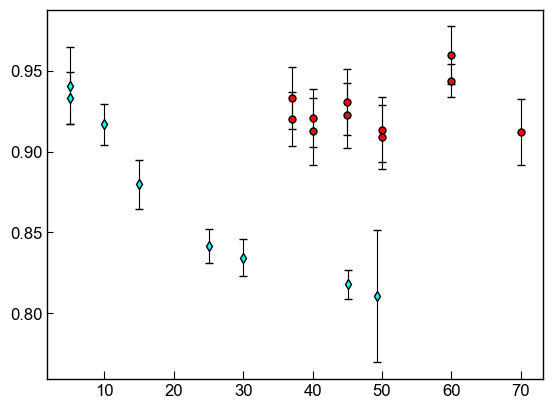

In [ ]:
plt.errorbar(df_Fogo_MI_power['power (mW)'], df_Fogo_MI_power['Density g/cm3'],
             xerr=0, yerr=df_Fogo_MI_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)


plt.errorbar(df_Fogo_MI_heat['T (C)'], df_Fogo_MI_heat['Density g/cm3'],
             xerr=0, yerr=df_Fogo_MI_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)


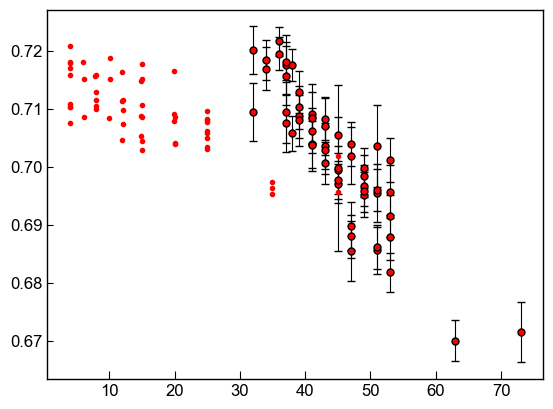

In [ ]:
plt.errorbar(df_a13_heat['T (C)'], df_a13_heat['Density g/cm3'],
             xerr=0, yerr=df_a13_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')


plt.plot(df_a13_power['power (mW)'], df_a13_power['Density g/cm3'], '.r')

<ErrorbarContainer object of 3 artists>

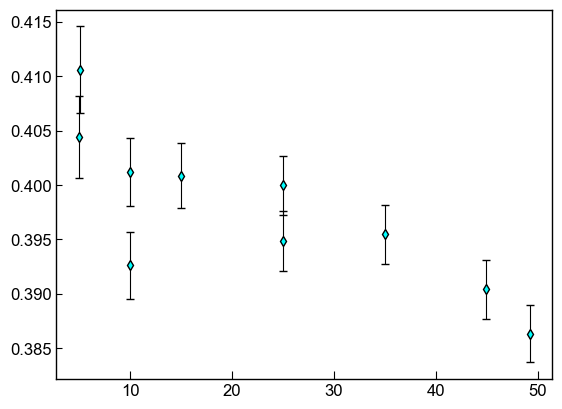

In [ ]:
plt.errorbar(df_IS_power_c2['power (mW)'], df_IS_power_c2['Density g/cm3'],
             xerr=0, yerr=df_IS_power_c2['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power')


## For Fogo


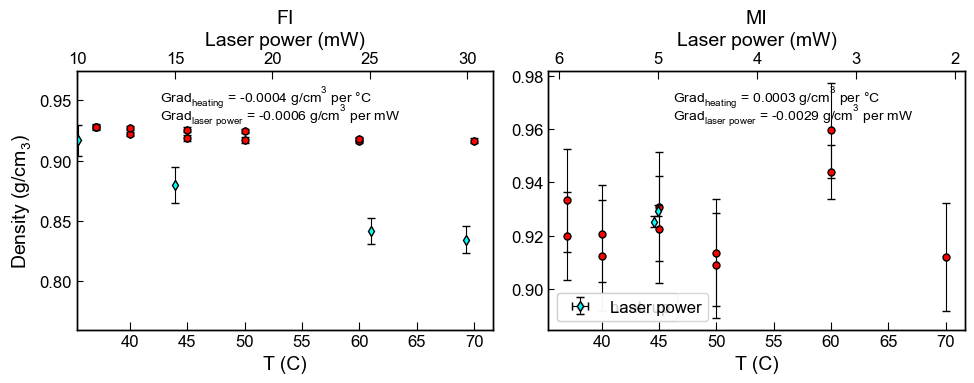

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10,4))


# === PLOT B30_c1 ===
ax1.errorbar(df_Fogo_FI_heat['T (C)'], df_Fogo_FI_heat['Density g/cm3'],
             xerr=0, yerr=df_Fogo_FI_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)


# === PLOT B23_c3 ===
ax2.errorbar(df_Fogo_MI_heat['T (C)'], df_Fogo_MI_heat['Density g/cm3'],
             xerr=0, yerr=df_Fogo_MI_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')

# ax2.plot(df_Fogo_FI_heat['T (C)'].loc[down], df_Fogo_FI_heat['Density g/cm3'].loc[down], 'ok', zorder=100, label='heat: down')


# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax3.errorbar(df_Fogo_FI_power['power (mW)'], df_Fogo_FI_power['Density g/cm3'],
             xerr=0, yerr=df_Fogo_FI_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power')

ax4.errorbar(df_Fogo_MI_power['power (mW)'], df_Fogo_MI_power['Density g/cm3'],
             xerr=0, yerr=df_Fogo_MI_power['σ Density g/cm3'],
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power')

# === FIT LINES ===
# For FI(T vs Density)

x_c1 = df_Fogo_FI_heat['T (C)']
y_c1 = df_Fogo_FI_heat['Density g/cm3']
slope_c1, intercept_c1, *_ = linregress(x_c1, y_c1)
x_fit_c1 = np.linspace(x_c1.min(), x_c1.max(), 100)
y_fit_c1 = slope_c1 * x_fit_c1 + intercept_c1
#ax1.plot(x_fit_c1, y_fit_c1, '--k', label='Fit: heat')

# For B23_c3 (T vs Density)
x_c3 = df_Fogo_MI_heat['T (C)']
y_c3 = df_Fogo_MI_heat['Density g/cm3']
slope_c3, intercept_c3, *_ = linregress(x_c3, y_c3)
x_fit_c3 = np.linspace(x_c3.min(), x_c3.max(), 100)
y_fit_c3 = slope_c3 * x_fit_c3 + intercept_c3
#ax2.plot(x_fit_c3, y_fit_c3, '--k', label='Fit: heat')

# === OPTIONAL: Fit laser power slopes (just for info) ===
# For B30_c1 laser
x_power_c1 = df_Fogo_FI_power['power (mW)']
y_power_c1 = df_Fogo_FI_power['Density g/cm3']
slope_power_c1, intercept_power_c1, *_ = linregress(x_power_c1, y_power_c1)

# For B23_c3 laser
x_power_c3 = df_Fogo_MI_power['power (mW)']
y_power_c3 = df_Fogo_MI_power['Density g/cm3']
slope_power_c3, intercept_power_c3, *_ = linregress(x_power_c3, y_power_c3)

# === ALIGN LASER AXIS ===
# We want: slope_power / slope_heat ≈ dX_laser / dX_heat → scaling factor
# Reverse sign because T usually decreases Density (negative slope)
# For B30_c1: map laser power → equivalent T
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
# Do linear regression between power (x) and T_equiv (y)
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

# For B23_c3
T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)

# Now set xlims so that: 
# ax twin x = (T - offset) / scale → matches T axis
# So xlim in mW = scale * (T axis limits) + offset
Tlim1 = ax1.get_xlim()
Tlim2 = ax2.get_xlim()

ax4.set_xlim([(Tlim1[0] - offset_fit_c1) / scale_fit_c1, 
              (Tlim1[1] - offset_fit_c1) / scale_fit_c1])

ax3.set_xlim([(Tlim2[0] - offset_fit_c3) / scale_fit_c3, 
              (Tlim2[1] - offset_fit_c3) / scale_fit_c3])


# === FINAL LABELS ===
ax3.legend()
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.legend(loc='lower left')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('Density (g/cm$_3$)')
ax1.set_title('FI')
ax2.set_title('MI')

#=== Add annotations to ax1 (B30_c1) ===
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} g/cm$^3$ per °C", 
             xy=(0.2, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.4f} g/cm$^3$ per mW", 
             xy=(0.2, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)


# === Add annotations to ax2 (B23_c3) ===
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} g/cm$^3$ per °C", 
             xy=(0.3, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.4f} g/cm$^3$ per mW", 
             xy=(0.3, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)



plt.tight_layout()

fig.savefig('TestTemp.png', dpi=300)


In [ ]:
df_P=pd.read_excel(r'C:\Users\penny\Box\Berkeley_new\Raman\Raman technical paper\Laser_power_Series\A11_4_TempSeries\Raman_session_November 15, 2023_fitted_2023-11-18.xlsx')
df_P['T (C)'] = df_P['filename'].apply(extract_temperature)
df_P.head()

,Unnamed: 0,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,Peak_Height_Carb,Model_name_y,Carb_Diad_Ratio,SO2_Diad_Ratio,SO2_mol_ratio,time,preferred_values,lower_values,upper_values,T (C)
0,0,A11-4_37C,0.514476,0.005154,0.004583,0.002357,103.966179,0.009817,0.000744,0.009811,...,6.641693,GaussianModel,0.047647,NaN,NaN,36847,0.997715,0.997708,0.997722,37
1,1,A11-4_40C,0.527851,0.004531,0.003869,0.002359,103.994733,0.008233,0.000735,0.008219,...,3.692247,GaussianModel,0.044244,NaN,NaN,37328,0.997707,0.997700,0.997714,40
2,2,A11-4_45C,0.539715,0.003889,0.003091,0.002360,104.019907,0.006540,0.000730,0.006514,...,6.532429,GaussianModel,0.051319,NaN,NaN,37648,0.997702,0.997695,0.997709,45
3,3,A11-4_50C,0.522594,0.002961,0.001790,0.002358,103.983533,0.003820,0.000722,0.003759,...,10.184363,GaussianModel,0.043878,NaN,NaN,38153,0.997693,0.997687,0.997700,50
4,4,A11-4_55C,0.534492,0.002968,0.001800,0.002360,104.008844,0.003819,0.000718,0.003759,...,6.420817,GaussianModel,0.029538,NaN,NaN,38437,0.997689,0.997682,0.997696,55


[-0.00135602]
0.004245939561930841


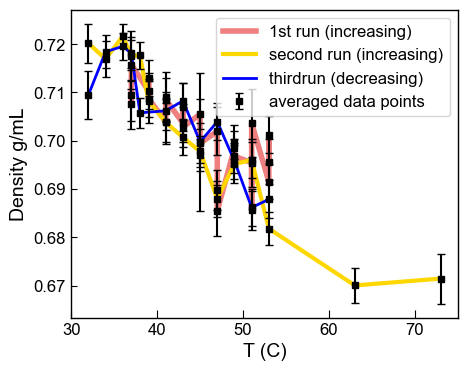

In [ ]:
data=df_a13_heat
first=data['filename'].str.contains('C-1|C-2|C-3')
second=data['filename'].str.contains('C-4')
third=data['filename'].str.contains('C-5')

fig,ax=plt.subplots(1,1,figsize=(5,4))

ax.errorbar(x=data['T (C)'][first],y=data['Density g/cm3'][first],fmt='-',linewidth=4,capsize=3,ecolor='lightgrey',color='lightcoral',zorder=-2,label='1st run (increasing)')
ax.errorbar(x=data['T (C)'][second],y=data['Density g/cm3'][second],fmt='-',linewidth=3,capsize=3,ecolor='lightgrey',color='gold',zorder=-2,label='second run (increasing)')
ax.errorbar(x=data['T (C)'][third],y=data['Density g/cm3'][third],fmt='-',linewidth=2,capsize=3,ecolor='lightgrey',color='blue',zorder=-2,label='thirdrun (decreasing)')
# ax.errorbar(x=data['T (C)'][first],y=data['Density g/cm3'][first],yerr=data['σ Density g/cm3'][first],fmt='-',capsize=3,ecolor='lightgrey',color='pink',zorder=-2,label='individual data point')
# ax.errorbar(x=data['T (C)'][second],y=data['Density g/cm3'][second],yerr=data['σ Density g/cm3'][second],fmt='-',capsize=3,ecolor='lightgrey',color='orange',zorder=-2,label='individual data point')
# ax.errorbar(x=data['T (C)'][third],y=data['Density g/cm3'][third],yerr=data['σ Density g/cm3'][third],fmt='-',capsize=3,ecolor='lightgrey',color='skyblue',zorder=-2,label='individual data point')

ax.set_xlabel("T (C)")
ax.set_ylabel("Density g/mL")

ax.errorbar(x=data['T (C)'],y=data['Density g/cm3'],yerr=data['σ Density g/cm3'],fmt='s',markersize=5,capsize=3,ecolor='k',color='k',zorder=-1,label='averaged data points')
ax.legend()

import Thermobar as pt
stats_charlotte=pt.calculate_R2(data['T (C)'], data['Density g/cm3'])
print(stats_charlotte['Grad'])
#print(stats_charlotte['Grad_err'])

print(np.nanmean(data['σ Density g/cm3']))

## Lets do Charlottes ones

Text(0.5, 1.0, 'FIC')

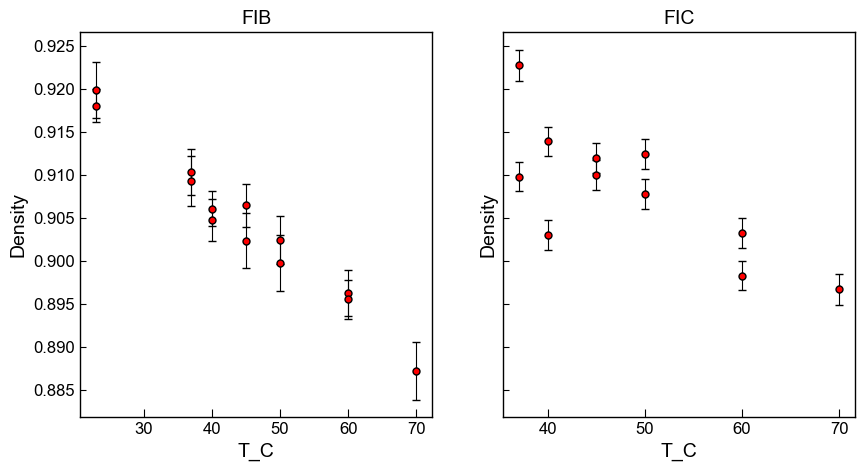

In [ ]:
# === PLOT B30_c1 ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5), sharey=True)
ax1.errorbar(df_101B_heat['T (C)'], df_101B_heat['Density g/cm3'],
             xerr=0, yerr=df_101B_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_xlabel('T_C')
ax1.set_ylabel('Density')
ax1.set_title('FIB')

ax2.errorbar(df_101C_heat['T (C)'], df_101C_heat['Density g/cm3'],
             xerr=0, yerr=df_101C_heat['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax2.set_xlabel('T_C')
ax2.set_ylabel('Density')
ax2.set_title('FIC')
# ax2.errorbar(df_101C_heat['T (C)'], df_101C_heat['Density g/cm3'],
#              xerr=0, yerr=df_101B_heat['σ Density g/cm3'],
#              fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)




C:\Users\penny\AppData\Local\Temp\ipykernel_19068\519527626.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_101B_heat['HB_diad']=calculate_HB_area(df_101B_heat)
C:\Users\penny\AppData\Local\Temp\ipykernel_19068\519527626.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_101C_heat['HB_diad']=calculate_HB_area(df_101C_heat)


Text(0.5, 1.0, 'FIC')

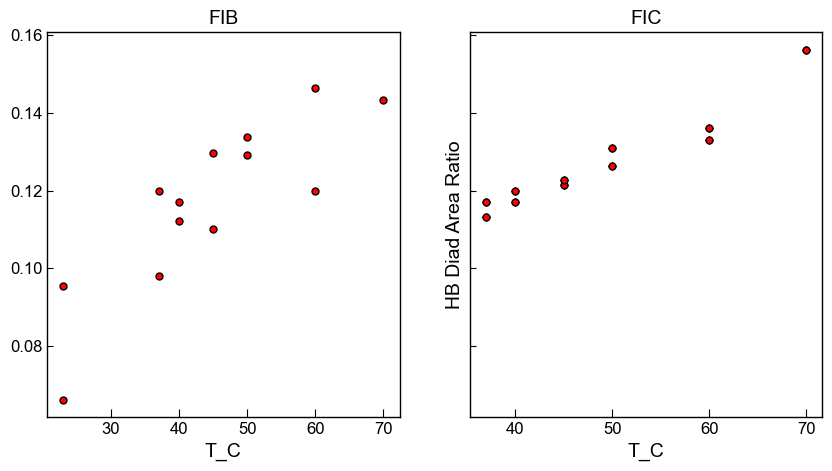

In [ ]:
# === PLOT B30_c1 ===
def calculate_HB_area(df):
    HB_diad=(df['HB2_Area']+df['HB1_Area'])/((df['Diad1_Voigt_Area']+df['Diad2_Voigt_Area']))
    return HB_diad

df_101B_heat['HB_diad']=calculate_HB_area(df_101B_heat)
df_101C_heat['HB_diad']=calculate_HB_area(df_101C_heat)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5), sharey=True)
ax1.errorbar(df_101B_heat['T (C)'], df_101B_heat['HB_diad'],
             
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_xlabel('T_C')

ax1.set_title('FIB')

ax2.errorbar(df_101C_heat['T (C)'], df_101C_heat['HB_diad'],
             xerr=0, yerr=0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax2.set_xlabel('T_C')
ax2.set_ylabel('HB Diad Area Ratio')
ax2.set_title('FIC')
# ax2.errorbar(df_101C_heat['T (C)'], df_101C_heat['Density g/cm3'],
#              xerr=0, yerr=df_101B_heat['σ Density g/cm3'],
#              fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)




C:\Users\penny\AppData\Local\Temp\ipykernel_19068\1210512374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_101B_power['HB_diad']=calculate_HB_area(df_101B_power)
C:\Users\penny\AppData\Local\Temp\ipykernel_19068\1210512374.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_101C_power['HB_diad']=calculate_HB_area(df_101C_power)


<ErrorbarContainer object of 3 artists>

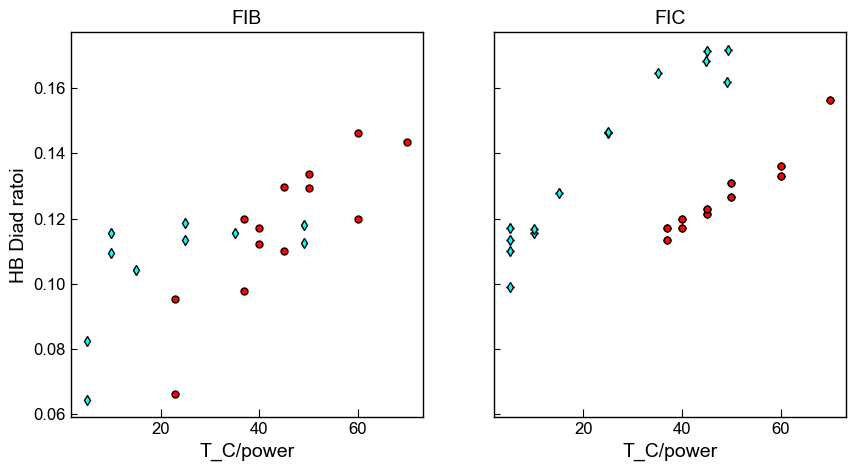

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5), sharey=True)
df_101B_power['HB_diad']=calculate_HB_area(df_101B_power)
df_101C_power['HB_diad']=calculate_HB_area(df_101C_power)
ax1.errorbar(df_101B_power['power (mW)'], df_101B_power['HB_diad'],
             
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3)

ax1.set_xlabel('power')
ax1.set_ylabel('HB Diad ratoi')

ax1.set_title('FIB')
ax2.set_title('FIC')
ax2.errorbar(df_101C_power['power (mW)'], df_101C_power['HB_diad'],
             xerr=0, yerr=0,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3)

ax1.errorbar(df_101B_heat['T (C)'], df_101B_heat['HB_diad'],
             
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_xlabel('T_C/power')

ax1.set_title('FIB')
ax2.set_xlabel('T_C/power')

ax2.errorbar(df_101C_heat['T (C)'], df_101C_heat['HB_diad'],
             xerr=0, yerr=0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

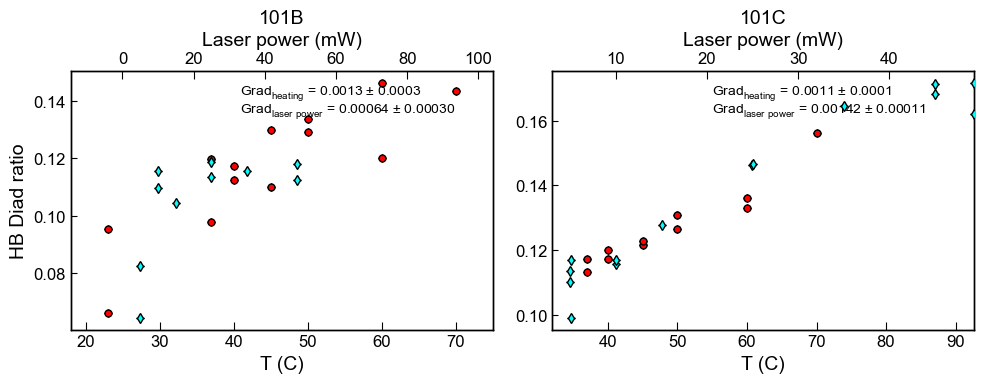

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define masks

# === TEMP SERIES ===
ax1.errorbar(df_101B_heat['T (C)'], df_101B_heat['HB_diad'],
             xerr=0, yerr=df_101B_heat['HB_diad']*0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.set_title('101B')

# === second series ===
ax2.set_title('101C')
ax2.errorbar(df_101C_heat['T (C)'], df_101C_heat['HB_diad'],
             xerr=0, yerr=df_101C_heat['HB_diad']*0,
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='heat: up')



# === DUPLICATE X AXES ===
ax3 = ax2.twiny()
ax4 = ax1.twiny()

# === Laser power data ===
ax4.errorbar(df_101B_power['power (mW)'], df_101B_power['HB_diad'],
             xerr=0, yerr=df_101B_power['HB_diad']*0,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

ax3.errorbar(df_101C_power['power (mW)'], df_101C_power['HB_diad'],
             xerr=0, yerr=df_101C_power['HB_diad']*0,
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='Laser power', zorder=100)

# === FIT LINES AND ERRORS ===
# Heating - B30_c1

x_c1 = df_101B_heat['T (C)']
y_c1 = df_101B_heat['HB_diad']
res_c1 = linregress(x_c1, y_c1)
slope_c1, intercept_c1, stderr_c1 = res_c1.slope, res_c1.intercept, res_c1.stderr


# Laser - B30_c1
x_power_c1 = df_101B_power['power (mW)']
y_power_c1 = df_101B_power['HB_diad']
res_power_c1 = linregress(x_power_c1, y_power_c1)
slope_power_c1, intercept_power_c1, stderr_power_c1 = res_power_c1.slope, res_power_c1.intercept, res_power_c1.stderr


# # Heating - B23_c3
x_c3 = df_101C_heat['T (C)']
y_c3 = df_101C_heat['HB_diad']
res_c3 = linregress(x_c3, y_c3)
slope_c3, intercept_c3, stderr_c3 = res_c3.slope, res_c3.intercept, res_c3.stderr


# Laser - B23_c3
x_power_c3 = df_101C_power['power (mW)']
y_power_c3 = df_101C_power['HB_diad']
res_power_c3 = linregress(x_power_c3, y_power_c3)
slope_power_c3, intercept_power_c3, stderr_power_c3 = res_power_c3.slope, res_power_c3.intercept, res_power_c3.stderr

# === B and propagated error ===
B_c1 = slope_power_c1 / slope_c1
B_err_c1 = B_c1 * np.sqrt((stderr_power_c1 / slope_power_c1)**2 + (stderr_c1 / slope_c1)**2)

B_c3 = slope_power_c3 / slope_c3
B_err_c3 = B_c3 * np.sqrt((stderr_power_c3 / slope_power_c3)**2 + (stderr_c3 / slope_c3)**2)

# === ALIGN LASER AXIS ===
T_equiv_c1 = (y_power_c1 - intercept_c1) / slope_c1
scale_fit_c1, offset_fit_c1, *_ = linregress(x_power_c1, T_equiv_c1)

T_equiv_c3 = (y_power_c3 - intercept_c3) / slope_c3
scale_fit_c3, offset_fit_c3, *_ = linregress(x_power_c3, T_equiv_c3)


##  Align X axis to give right gradients ################
######################################################333

# --- Define data and fit params for 101B ---
T_heat1 = df_101B_heat['T (C)']
P_power1 = df_101B_power['power (mW)']
scale1, offset1 = scale_fit_c1, offset_fit_c1

# --- Define data and fit params for FGO4 ---
T_heat2 =  df_101C_heat['T (C)']
P_power2 =  df_101C_power['power (mW)']
scale2, offset2 = scale_fit_c3, offset_fit_c3

# === Function to compute consistent axis limits ===
def compute_axes(T_heat, P_power, scale, offset):
    # Pad temperature range
    T_min_pad = T_heat.min() - 5
    T_max_pad = T_heat.max() + 5

    # Get equivalent T from full laser power range
    T_from_P_min = scale * P_power.min() + offset
    T_from_P_max = scale * P_power.max() + offset

    # Use the full extent needed for T axis
    T_final_min = min(T_min_pad, T_from_P_min)
    T_final_max = max(T_max_pad, T_from_P_max)

    # Back-calculate power axis limits from final T range
    P_final_min = (T_final_min - offset) / scale
    P_final_max = (T_final_max - offset) / scale

    return (T_final_min, T_final_max), (P_final_min, P_final_max)

# === Calculate and apply limits ===
(Tlim1_min, Tlim1_max), (Plim1_min, Plim1_max) = compute_axes(T_heat1, P_power1, scale1, offset1)
(Tlim2_min, Tlim2_max), (Plim2_min, Plim2_max) = compute_axes(T_heat2, P_power2, scale2, offset2)

ax1.set_xlim(Tlim1_min, Tlim1_max)
ax2.set_xlim(Tlim2_min, Tlim2_max)
ax4.set_xlim(Plim1_min, Plim1_max)
ax3.set_xlim(Plim2_min, Plim2_max)



# === FINAL LABELS ===
ax3.set_xlabel('Laser power (mW)')
ax4.set_xlabel('Laser power (mW)')
ax1.set_xlabel('T (C)')
ax2.set_xlabel('T (C)')
ax1.set_ylabel('HB Diad ratio')



# Annotations for B30_c1
ax1.annotate(f"Grad$_{{heating}}$ = {slope_c1:.4f} ± {stderr_c1:.4f}",
             xy=(0.4, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax1.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c1:.5f} ± {stderr_power_c1:.5f}",
             xy=(0.4, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)


# Annotations for B23_c3
ax3.annotate(f"Grad$_{{heating}}$ = {slope_c3:.4f} ± {stderr_c3:.4f}",
             xy=(0.38, 0.95), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)

ax3.annotate(f"Grad$_{{laser\\ power}}$ = {slope_power_c3:.5f} ± {stderr_power_c3:.5f}",
             xy=(0.38, 0.88), xycoords='axes fraction',
             ha='left', va='top', fontsize=10)


plt.tight_layout()
fig.savefig('TestTemp_101C_101B.png', dpi=300)


NameError: name 'df_D_power_FIC' is not defined

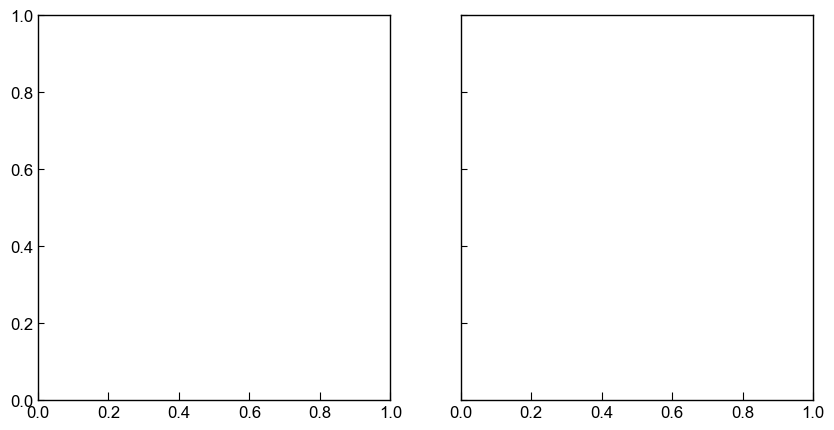

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5), sharey=True)
down=df_D_power_FIC['filename'].str.contains('down')

down_B=df_D_power_FIB['filename'].str.contains('down')
ax1.errorbar(df_D_power_FIB['power (mW)'], df_D_power_FIB['Density g/cm3'],
             xerr=0, yerr=df_D_power_FIB['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax1.errorbar(df_D_power_FIB['power (mW)'].loc[down_B], df_D_power_FIB['Density g/cm3'].loc[down_B],
             xerr=0, yerr=df_D_power_FIB['σ Density g/cm3'].loc[down_B],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='black', ms=10, mec='k', capsize=3, label='down')

ax2.errorbar(df_D_power_FIC['power (mW)'], df_D_power_FIC['Density g/cm3'],
             xerr=0, yerr=df_D_power_FIC['σ Density g/cm3'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)

ax2.errorbar(df_D_power_FIC['power (mW)'].loc[down], df_D_power_FIC['Density g/cm3'].loc[down],
             xerr=0, yerr=df_D_power_FIC['σ Density g/cm3'].loc[down],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='black', ms=10, mec='k', capsize=3, label='down')
ax1.legend()

ax1.set_title('FIB - Has spinel - 17 um deep')
ax2.set_title('FIC - 2um deep')
ax1.set_xlabel('power')
ax1.set_ylabel('density')

In [ ]:
## calxulate the isochrore for 0.9 and 0.7 
P_SW96_09=pf.calculate_P_for_rho_T(
CO2_dens_gcm3=0.9, T_K=np.linspace(33, 120,50)+273.15, EOS='SW96')


In [ ]:
pf.calculate_rho_for_P_T(T_K=23+273.15, P_kbar=7.2/100)
pf.calculate_rho_for_P_T(T_K=200+273.15, P_kbar=7.2/100)

In [ ]:
P_SW96_09=pf.calculate_P_for_rho_T(
CO2_dens_gcm3=0.9, T_K=np.linspace(33, 120,50)+273.15, EOS='SW96')

P_SW96_07=pf.calculate_P_for_rho_T(
CO2_dens_gcm3=0.7, T_K=np.linspace(33, 120,50)+273.15, EOS='SW96')


plt.plot(P_SW96_09['T_K']-273.15,P_SW96_09['P_kbar'], '-r', label='0.9 g/cm3' )
plt.plot(P_SW96_07['T_K']-273.15,P_SW96_07['P_kbar'], '-b' , label='0.7 g/cm3')
plt.legend()
plt.xlabel('T (C)')
plt.ylabel('Internal P (kbar)')

In [ ]:
df_D_power_FIC

## subblets equation

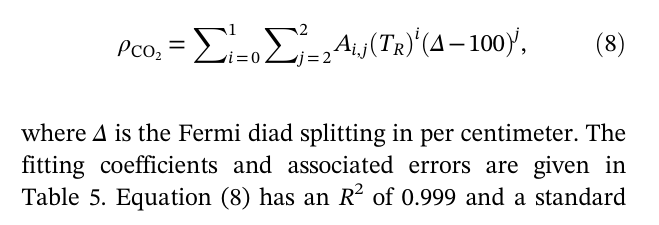
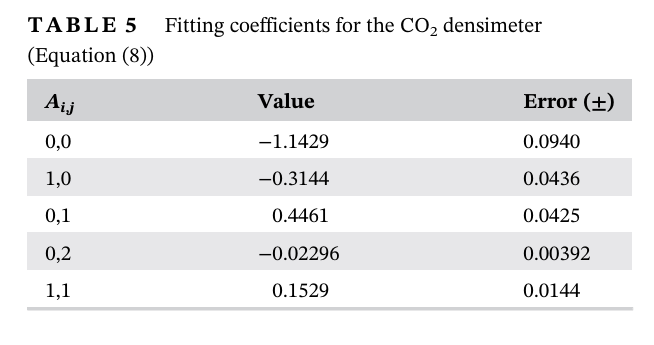

In [ ]:

def rho_CO2(Delta, T_K):

    TR=T_K/(31.1+273.15)
    # Define the coefficients A_ij as a dictionary (i, j): value
    A = {
        (0, 0): -1.1429,
        (1, 0): -0.3144,
        (0, 1):  0.4461,
        (0, 2): -0.02296,
        (1, 1):  0.1529
    }

    # Compute rho_CO2 as per the equation
    rho = 0
    for (i, j), value in A.items():
        rho += value * (TR ** i) * ((Delta - 100) ** j)

    return rho

In [ ]:
rho_CO2(Delta=103, T_K=273.15+37)

## nice plot showing the density difference

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define Delta range for plotting
Delta = np.linspace(102.8, 110, 100)

# Define list of temperatures in Celsius for first plot
Temps_C = [37, 50, 100, 150, 200, 250]

# Set up color map
cmap = cm.get_cmap('viridis', len(Temps_C))
colors = cmap.colors if hasattr(cmap, 'colors') else [cmap(i/len(Temps_C)) for i in range(len(Temps_C))]

# Prepare figure: 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=False)

# First: fit polynomial at 37 °C
T_fit_C = 37
T_fit_K = 273.15 + T_fit_C
x_fit = np.linspace(102.8, 105, 100)
y_fit = rho_CO2(x_fit, T_K=T_fit_K)

degree = 3  # You can adjust degree!
coeffs = np.polyfit(x_fit, y_fit, degree)
p = np.poly1d(coeffs)

# Loop over temperatures for main plot + second plot
for i, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C
    
    # Calculate density on full Delta range
    Rho_CO2_full = rho_CO2(Delta, T_K=T_K)
    
    # Filter to valid pressures
    EOS_check = pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2_full, T_K=T_K)
    Keep = EOS_check['P_MPa'].between(1, 50)
    
    # Plot main density vs Delta curve
    ax1.plot(Delta[Keep], Rho_CO2_full[Keep], '-', color=colors[i], label=f'{T_C} °C')
    
    # Now use 37 °C polynomial to predict
    Rho_poly_at_T = p(Delta)
    
    # Plot density vs difference
    ax2.plot(Rho_CO2_full[Keep],  Rho_poly_at_T[Keep]-Rho_CO2_full[Keep], 
             '-', color=colors[i], label=f'{T_C} °C')

# Labeling main plot
ax1.set_xlabel('Splitting')
ax1.set_ylabel('CO$_2$ Density (g/cm$^3$)')
ax1.legend(title='Temperature')
ax1.set_title('Density vs Splitting')

# Labeling difference plot
ax2.set_xlabel('CO$_2$ Density (g/cm$^3$)')
ax2.set_ylabel('Density Difference (g/cm$^3$)\n(Actual - Poly 37°C)')
ax2.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax2.legend(title='Temperature')
ax2.set_title('Fit Error vs CO$_2$ Density')

ax2.set_xlim([0, 1])
ax2.set_ylim([0, -0.3])

# Tidy layout
plt.tight_layout()
plt.show()



## Lets do the same for Hagiwara

In [ ]:
def calculate_CO2_rho_H21(split, T_K):
    T_C=T_K-273.15
    a=-61821.3575
    b=-3.3585*10**-4
    c=1.56567*10**-8
    d=1781.1957586
    e=-17.112171653
    f=0.0548181541
    g=0.00119219
    h=-0.0000112203
    i=3.12805*10**-6
    j=-1.02847*10**-46

    CO2_dens=a + b*T_C**2 + c*T_C**3 + d*split +   e * split**2 + f* split**3 + g*split*T_C + h*split**2*T_C + i*split*T_C**2 + j*np.exp(split)

    return CO2_dens


## Calculate the offset. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d
import Thermobar as pt

# Assume df_IS, df_I, df_a13_heat, df_101B_heat, df_Fogo_FI_heat, B23, B30, rho_CO2, p, calculate_CO2_rho_H21, p_H21 are preloaded

# --- Setup ---
Delta = np.linspace(102.8, 105, 200)
Temps_C = np.linspace(37, 250, 100)

# --- Full dataset: labels, colors, data ---
full_data = [
    ('IS',       'gold',     df_IS['T (C)'], df_IS['Density g/cm3']),
    ('B23',      'seagreen', df_I['T (C)'].loc[B23], df_I['Density g/cm3'].loc[B23]),
    ('A13',      'darkviolet', df_a13_heat['T (C)'], df_a13_heat['Density g/cm3']),
    ('B30',      'black',    df_I['T (C)'].loc[B30], df_I['Density g/cm3'].loc[B30]),
    ('FIB',      'cyan',     df_101B_heat['T (C)'], df_101B_heat['Density g/cm3']),
    ('Fogo_FI',  'darkred',  df_Fogo_FI_heat['T (C)'], df_Fogo_FI_heat['Density g/cm3']),
]

# --- Separate IS from the rest ---
IS_label, IS_color, IS_T, IS_dens = full_data[0]
rest_data = full_data[1:]

# --- Function to calculate stats and extract values ---
def get_stats_and_val(T, dens):
    stats = pt.calculate_R2(T, dens)
    rho_37 = stats['Grad'][0] * 37 + stats['Int'].item()
    stats_diff = pt.calculate_R2(T, rho_37 - dens)
    grad = stats['Grad']
    grad_err = stats['Grad_err']
    return rho_37, stats_diff, grad, grad_err

# --- Process IS first ---
rho_37_IS, stats_diff_IS, grad_IS, grad_err_IS = get_stats_and_val(IS_T, IS_dens)
processed = [{
    'label': IS_label,
    'color': IS_color,
    'T': IS_T,
    'dens': IS_dens,
    'rho_37': rho_37_IS,
    'stats': stats_diff_IS,
    'grad': grad_IS,
    'grad_err': grad_err_IS
}]

# --- Process and sort the rest ---
rest_processed = []
for label, color, T, dens in rest_data:
    rho_37, stats_diff, grad, grad_err = get_stats_and_val(T, dens)
    rest_processed.append({
        'label': label,
        'color': color,
        'T': T,
        'dens': dens,
        'rho_37': rho_37,
        'stats': stats_diff,
        'grad': grad,
        'grad_err': grad_err
    })

# --- Sort the rest by rho_37 ---
rest_processed_sorted = sorted(rest_processed, key=lambda d: d['rho_37'])

# --- Combine full ordered data ---
all_data = processed + rest_processed_sorted

# --- Create summary table ---
summary_data = {
    'Dataset': [d['label'] for d in all_data],
    'Density 37 (g/cm³)': [d['rho_37'] for d in all_data],
    'Gradient (g/cm³/°C)': [d['grad'] for d in all_data],
    'Gradient error (g/cm³/°C)': [d['grad_err'] for d in all_data],
    'Difference (g/cm³)': [d['grad'] * (70 - 37) for d in all_data],
    'Difference error (g/cm³)': [d['grad_err'] * (70 - 37) for d in all_data]
}
summary_df = pd.DataFrame(summary_data)


In [ ]:
grad_chec=summary_df['Gradient (g/cm³/°C)']*(80-37)
grad_chec

## Plot panel for paper

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec

# Define Delta range for plotting
Delta = np.linspace(102.8, 105, 100)
Temps_C = [37, 70, 150, 200]

# Set up color map
cmap = cm.get_cmap('magma', len(Temps_C)+1)
colors = cmap.colors if hasattr(cmap, 'colors') else [cmap(i / len(Temps_C)) for i in range(len(Temps_C))]

# Create figure and GridSpec
fig = plt.figure(figsize=(13.4, 5))
gs = GridSpec(nrows=1, ncols=4, width_ratios=[0.8, 0.8, 0.1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[3])

# Fit at 37 C for baseline polynomial
T_fit_C = 37
T_fit_K = 273.15 + T_fit_C
x_fit = np.linspace(102.8, 105, 200)
y_fit_orig = rho_CO2(x_fit, T_K=T_fit_K)
p_orig = np.poly1d(np.polyfit(x_fit, y_fit_orig, 3))

y_fit_H21 = calculate_CO2_rho_H21(split=x_fit, T_K=T_fit_K)
p_H21 = np.poly1d(np.polyfit(x_fit, y_fit_H21, 3))

## Actual plotting loop
for i, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C

    # === ORIGINAL MODEL ===
    Rho_orig = rho_CO2(Delta, T_K=T_K)
    EOS_check = pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_orig, T_K=T_K)
    Keep_orig = EOS_check['P_MPa'].between(1, 50)

    # Plot full on ax1
    ax1.plot(Delta[Keep_orig], Rho_orig[Keep_orig], '-', color=colors[i], label=f'{T_C} °C')
    
    # Plot full on ax3: split into valid and extrapolated
    ax3.plot(Rho_orig[Keep_orig], Rho_orig[Keep_orig] - p_orig(Delta[Keep_orig]), '--', color=colors[i], linewidth=2.5)

    NotKeep = ~Keep_orig
    if NotKeep.any():
        ax3.plot(Rho_orig[NotKeep], Rho_orig[NotKeep] - p_orig(Delta[NotKeep]), '-', color=colors[i], linewidth=0.5)



    # === H21 MODEL ===
    Rho_H21 = calculate_CO2_rho_H21(split=Delta, T_K=T_K)
    Keep_H21 = (Rho_H21 > 0.7) & (Rho_H21 < 1.2)

    # Plot full on ax2
    ax2.plot(Delta[Keep_H21], Rho_H21[Keep_H21], '-', color=colors[i])

    # Plot on ax3: split into valid and extrapolated
    ax3.plot(Rho_H21[Keep_H21], Rho_H21[Keep_H21] - p_H21(Delta[Keep_H21]), ':', color=colors[i], linewidth=2.5)

    NotKeep_H21 = ~Keep_H21
    if NotKeep_H21.any():
        ax3.plot(Rho_H21[NotKeep_H21], Rho_H21[NotKeep_H21] - p_H21(Delta[NotKeep_H21]),
                 '-', color=colors[i], linewidth=0.5)

 

# Axis labels
ax1.set_xlabel('Splitting (Δ)')
ax1.set_ylabel('CO$_2$ Density (g/cm$^3$)')
ax1.legend()

ax2.set_xlabel('Splitting (Δ)')
ax2.tick_params(labelleft=False)

ax3.set_xlabel('CO$_2$ Density (g/cm$^3$)')
ax3.set_ylabel('Density Difference (g/cm$^3$)\n(True - Calc using 37°C densimeter)')
ax3.axhline(0, linestyle='--', color='gray', linewidth=0.8)

# Limits
for ax in [ax1, ax2]:
    ax.set_xlim([102.75, 105.1])
    ax.set_ylim([0, 1.1])
    ax.set_xticks([103, 103.5, 104, 104.5, 105])

# Adjust layout manually to remove space between ax1 and ax2
fig.subplots_adjust(left=0.07, right=0.95, top=0.95, bottom=0.15, wspace=0.0)
ax3.set_position([
    ax2.get_position().x1 + 0.08,  # x
    ax2.get_position().y0,        # y
    ax2.get_position().width,     # width
    ax2.get_position().height     # height
])

idx_70 = Temps_C.index(70)
color_for_70 = colors[idx_70]

# Predicted change: gradient * (70 - 37)
delta_T = 70 - 37
grad_chec = summary_df['Gradient (g/cm³/°C)'] * delta_T
grad_err_chec = summary_df['Gradient error (g/cm³/°C)'] * delta_T

ax3.errorbar(
    summary_df['Density 37 (g/cm³)'],
    -grad_chec,
    yerr=grad_err_chec,
    fmt='ok',
    mfc=color_for_70,
    capsize=3,
    label='Predicted Δρ (37→70 °C)'
)

ax3.set_xlim([0, 1.1])
ax3.set_ylim([-0.01, 0.25])
#fig.tight_layout()
fig.savefig('Temp_Sensitivity_FINAL.png', dpi=300, transparent=True)


In [ ]:
# Define Delta range for plotting
Delta = np.linspace(102.8, 105, 100)

# Define list of temperatures in Celsius for plot
Temps_C = [37, 60, 80, 150, 200, 250]

# Set up color map
cmap = cm.get_cmap('viridis', len(Temps_C))
colors = cmap.colors if hasattr(cmap, 'colors') else [cmap(i/len(Temps_C)) for i in range(len(Temps_C))]

# Prepare figure: 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharex=False)

# --- ORIGINAL POLY ---
T_fit_C = 37
T_fit_K = 273.15 + T_fit_C
x_fit_orig = np.linspace(102.8, 105, 200)
y_fit_orig = rho_CO2(x_fit_orig, T_K=T_fit_K)

degree = 3
coeffs_orig = np.polyfit(x_fit_orig, y_fit_orig, degree)
p_orig = np.poly1d(coeffs_orig)

# --- H21 POLY ---
x_fit_H21 = np.linspace(102.8, 105, 200)
y_fit_H21 = calculate_CO2_rho_H21(split=x_fit_H21, T_K=T_fit_K)

coeffs_H21 = np.polyfit(x_fit_H21, y_fit_H21, degree)
p_H21 = np.poly1d(coeffs_H21)

# --- Loop over temperatures ---
for i, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C
    
    # --- ORIGINAL ---
    Rho_orig_full = rho_CO2(Delta, T_K=T_K)
    
    EOS_check = pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_orig_full, T_K=T_K)
    Keep_orig = EOS_check['P_MPa'].between(1, 50)
    
    # Plot Density vs Splitting — ORIGINAL → ax1
    ax1.plot(Delta[Keep_orig], Rho_orig_full[Keep_orig], '--', color=colors[i], label=f'{T_C} °C')
    
    # Fit error — ORIGINAL → ax3
    Rho_poly_orig = p_orig(Delta)
    ax3.plot(Rho_orig_full[Keep_orig], Rho_orig_full[Keep_orig] - Rho_poly_orig[Keep_orig],
             '--', color=colors[i])
    
    # --- H21 ---
    Rho_H21_full = calculate_CO2_rho_H21(split=Delta, T_K=T_K)
    Keep_H21 = (Rho_H21_full > 0.7) & (Rho_H21_full < 1.2)
    
    # Plot Density vs Splitting — H21 → ax2
    ax2.plot(Delta[Keep_H21], Rho_H21_full[Keep_H21], ':', color=colors[i], label=f'{T_C} °C')
    
    # Fit error — H21 → ax3
    Rho_poly_H21 = p_H21(Delta)
    ax3.plot(Rho_H21_full[Keep_H21], Rho_H21_full[Keep_H21] - Rho_poly_H21[Keep_H21],
             ':', color=colors[i])  # dashed line for H21 errors

# --- Final labels ---

# Subplot 1: ORIGINAL
ax1.set_xlabel('Splitting (Δ)')
ax1.set_ylabel('CO$_2$ Density (g/cm$^3$)')
ax1.legend()
#ax1.set_title('S21')

# Subplot 2: H21
ax2.set_xlabel('Splitting (Δ)')
ax2.set_ylabel('CO$_2$ Density (g/cm$^3$)')
#ax2.legend(title='Temperature')
#ax2.set_title('H21')

# Subplot 3: Fit Error (both models)
ax3.set_xlabel('CO$_2$ Density (g/cm$^3$)')
ax3.set_ylabel('Density Difference (g/cm$^3$)\n(True - Calc using 37°C densimeter)')
ax3.axhline(0, linestyle='--', color='gray', linewidth=0.8)
#ax3.set_title('Fit Error vs CO$_2$ Density\nSolid = Original, Dotted = H21')

# Optional:
# ax3.set_xlim([0.7, 1])
# ax3.set_ylim([0, 0.3])

ax2.set_ylim([0, 1.1])
ax1.set_ylim([0, 1.1])
ax1.set_xlim([102.75, 105.1])
ax2.set_xlim([102.75, 105.1])
ax1.set_xticks([103, 103.5, 104, 104.5, 105, ])
# Tidy layout
#plt.tight_layout()
plt.show()

fig.savefig('Temp_Sensitivity.png', dpi=300)

In [ ]:

def rho_CO2(Delta, T_K):

    TR=T_K/(31.1+273.15)
    # Define the coefficients A_ij as a dictionary (i, j): value
    A = {
        (0, 0): -1.1429,
        (1, 0): -0.3144,
        (0, 1):  0.4461,
        (0, 2): -0.02296,
        (1, 1):  0.1529
    }

    # Compute rho_CO2 as per the equation
    rho = 0
    for (i, j), value in A.items():
        rho += value * (TR ** i) * ((Delta - 100) ** j)

    return rho

In [ ]:
## Now lets make a fit for 37C for Hagiwara
x_fit_H21 = np.linspace(102.8, 105, 100)
y_fit_H21 = calculate_CO2_rho_H21(split=x_fit_H21, T_K=37+273.15)

degree = 3
coeffs_H21 = np.polyfit(x_fit_H21, y_fit_H21, degree)
p_H21= np.poly1d(coeffs_H21)

plt.plot(x_fit_H21, y_fit_H21, '+k')
plt.plot(x_fit_H21, p_H21(x_fit_H21), '-r')
plt.plot()

# and subplet

#  Fit polynomial at 37 C
T_fit_C = 37
T_fit_K = 273.15 + T_fit_C
x_fit = np.linspace(102.8, 105, 100)
y_fit = rho_CO2(x_fit, T_K=T_fit_K)

degree = 3
coeffs = np.polyfit(x_fit, y_fit, degree)
p = np.poly1d(coeffs)


In [ ]:
## Want a plot of Density vs. Temp for different CO2 temperatures. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d

# 1️⃣ Define temperature range
Temps_C = np.arange(37, 251, 5)  # 37 to 250 C
Delta = np.linspace(102.8, 105, 200)  # finer Delta grid

# 3️⃣ Target densities
Densities = np.linspace(0.715, 0.75, 1)

# 4️⃣ Result matrices
density_diffs_orig = np.full((len(Densities), len(Temps_C)), np.nan)
density_diffs_H21 = np.full((len(Densities), len(Temps_C)), np.nan)

# 5️⃣ Loop over T
for iT, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C
    
    # --- ORIGINAL ---
    Rho_CO2_actual = rho_CO2(Delta, T_K=T_K)
    Rho_poly = p(Delta)
    
    EOS_check = pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2_actual, T_K=T_K)
    Keep_orig = EOS_check['P_MPa'].between(1, 50)
    
    Rho_valid_min_orig = np.min(Rho_CO2_actual[Keep_orig])
    Rho_valid_max_orig = np.max(Rho_CO2_actual[Keep_orig])

    interp_actual = interp1d(Rho_CO2_actual, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly = interp1d(Delta, Rho_poly, bounds_error=False, fill_value='extrapolate')
    
    # --- H21 ---
    Rho_CO2_H21 = calculate_CO2_rho_H21(Delta, T_K=T_K)
    Rho_poly_H21 = p_H21(Delta)
    
    Keep_H21 = (Rho_CO2_H21 > 0.7) & (Rho_CO2_H21 < 1.2)
    Rho_valid_min_H21 = np.min(Rho_CO2_H21[Keep_H21])
    Rho_valid_max_H21 = np.max(Rho_CO2_H21[Keep_H21])

    interp_actual_H21 = interp1d(Rho_CO2_H21, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly_H21 = interp1d(Delta, Rho_poly_H21, bounds_error=False, fill_value='extrapolate')
    

    # --- Target densities ---
    for iD, D_target in enumerate(Densities):
        # ORIGINAL
        if D_target < Rho_valid_min_orig or D_target > Rho_valid_max_orig:
            density_diffs_orig[iD, iT] = np.nan
        else:
            Delta_target = interp_actual(D_target)
            Poly_at_target = interp_poly(Delta_target)
            density_diffs_orig[iD, iT] = D_target - Poly_at_target
        
        # H21
        if D_target < Rho_valid_min_H21 or D_target > Rho_valid_max_H21:
            density_diffs_H21[iD, iT] = np.nan
        else:
            Delta_target_H21 = interp_actual_H21(D_target)
            Poly_at_target_H21 = interp_poly_H21(Delta_target_H21)
            density_diffs_H21[iD, iT] = D_target - Poly_at_target_H21

# 7️⃣ Plot
fig, ax = plt.subplots(figsize=(8,6))
cmap = cm.get_cmap('viridis', len(Densities))

for i in range(len(Densities)):
    # Original = solid
    ax.plot(Temps_C, density_diffs_orig[i, :], '-', color=cmap(i), label=f'{Densities[i]:.2f} g/cm³ (orig)')
    # H21 = dashed
    ax.plot(Temps_C, density_diffs_H21[i, :], '--', color=cmap(i), label=f'{Densities[i]:.2f} g/cm³ (H21)')

# Experimental points
ax.plot(df_a13_heat['T (C)'], 0.715 - df_a13_heat['Density g/cm3'], 'ok', zorder=100)

# Labels
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density Difference (Actual - Poly 37°C) (g/cm³)')
ax.set_title('B30_c1: Density Difference vs Temperature\nOriginal vs H21')
ax.legend(title='Target Density', fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)

ax.set_xlim([20, 100])
ax.set_ylim([-0.01, 0.1])

plt.tight_layout()
plt.show()


## Other plot for paper

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d

# --- Setup ---
Delta = np.linspace(102.8, 105, 200)
Temps_C = np.linspace(37, 250, 100)

# --- Full dataset: labels, colors, data ---
full_data = [
    ('IS',       'gold',     df_IS['T (C)'], df_IS['Density g/cm3']),
    ('B23',      'seagreen', df_I['T (C)'].loc[B23], df_I['Density g/cm3'].loc[B23]),
    ('A13',      'darkviolet', df_a13_heat['T (C)'], df_a13_heat['Density g/cm3']),
    ('B30',      'black',    df_I['T (C)'].loc[B30], df_I['Density g/cm3'].loc[B30]),
    ('FIB',      'cyan',     df_101B_heat['T (C)'], df_101B_heat['Density g/cm3']),
    ('Fogo_FI',  'darkred',  df_Fogo_FI_heat['T (C)'], df_Fogo_FI_heat['Density g/cm3']),
]

# --- Separate IS from the rest ---
IS_label, IS_color, IS_T, IS_dens = full_data[0]
rest_data = full_data[1:]

# --- Calculate ρ at 37 °C and regress differences ---
def get_stats_and_val(T, dens):
    stats = pt.calculate_R2(T, dens)
    rho_37 = stats['Grad'][0] * 37 + stats['Int'].item()
    stats_diff = pt.calculate_R2(T, rho_37 - dens)
    return rho_37, stats_diff

# --- Process IS first ---
rho_37_IS, stats_diff_IS = get_stats_and_val(IS_T, IS_dens)
processed = [{
    'label': IS_label,
    'color': IS_color,
    'T': IS_T,
    'dens': IS_dens,
    'rho_37': rho_37_IS,
    'stats': stats_diff_IS
}]


# --- Process and sort the rest ---
rest_processed = []
for label, color, T, dens in rest_data:
    rho_37, stats_diff = get_stats_and_val(T, dens)
    rest_processed.append({
        'label': label,
        'color': color,
        'T': T,
        'dens': dens,
        'rho_37': rho_37,
        'stats': stats_diff
    })
    print(rho_37)

# --- Sort the rest by rho_37 ---
rest_processed_sorted = sorted(rest_processed, key=lambda d: d['rho_37'])

# --- Combine full ordered data ---
all_data = processed + rest_processed_sorted

# --- Collect ρ values at 37 °C for modeling ---
vals_at_37 = np.array([d['rho_37'] for d in all_data])
Densities = vals_at_37.copy()

# --- Initialize difference arrays ---
density_diffs_orig = np.full((len(Densities), len(Temps_C)), np.nan)
density_diffs_H21  = np.full((len(Densities), len(Temps_C)), np.nan)

# --- Loop over temperatures to compute modeled differences ---
for iT, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C

    Rho_CO2_actual = rho_CO2(Delta, T_K=T_K)
    Rho_poly = p(Delta)

    interp_actual = interp1d(Rho_CO2_actual, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly = interp1d(Delta, Rho_poly, bounds_error=False, fill_value='extrapolate')

    Rho_CO2_H21 = calculate_CO2_rho_H21(Delta, T_K=T_K)
    Rho_poly_H21 = p_H21(Delta)

    interp_actual_H21 = interp1d(Rho_CO2_H21, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly_H21 = interp1d(Delta, Rho_poly_H21, bounds_error=False, fill_value='extrapolate')

    for iD, D_target in enumerate(Densities):
        if D_target < np.min(Rho_CO2_actual) or D_target > np.max(Rho_CO2_actual):
            density_diffs_orig[iD, iT] = np.nan
        else:
            Delta_target = interp_actual(D_target)
            Poly_at_target = interp_poly(Delta_target)
            density_diffs_orig[iD, iT] = D_target - Poly_at_target

        if D_target < np.min(Rho_CO2_H21) or D_target > np.max(Rho_CO2_H21):
            density_diffs_H21[iD, iT] = np.nan
        else:
            Delta_target_H21 = interp_actual_H21(D_target)
            Poly_at_target_H21 = interp_poly_H21(Delta_target_H21)
            density_diffs_H21[iD, iT] = D_target - Poly_at_target_H21

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0, hspace=0)
axes = axes.flatten()  # Flatten 2D array into 1D for easier iteration


for i, ax in enumerate(axes):
    d = all_data[i]
    label, color, T_exp, dens_exp, rho_37, stats_exp = d['label'], d['color'], d['T'], d['dens'], d['rho_37'], d['stats']
    diff_exp = rho_37 - dens_exp

    # Model curves
    ax.plot(Temps_C, density_diffs_orig[i, :], '--', color=color, linewidth=2.5,
            label=f'{label} ({rho_37:.3f} g/cm³)') # this is Sublet, dashed lines
    ax.plot(Temps_C, density_diffs_H21[i, :], ':', color=color, linewidth=2.5) # This is H2021, dashed lines. 

    # Experimental data
    ax.plot(T_exp, diff_exp, 'ok', mfc=color, zorder=100)
    ax.plot(stats_exp['x_pred'], stats_exp['y_pred'], '-', color=color)

    # Annotation
    ax.annotate(f"{stats_exp['Grad'][0]:.4f}±{stats_exp['Grad_err']:.5f}\n g/cm$^3$/°C", 
                xy=(0.02, 0.7), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='k')

    
    ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlim([30, 80])
    ax.set_ylim([-0.01, 0.06])
    #ax.legend(fontsize=8, loc='upper left')

axes[3].set_xlabel('Temperature (°C)')
axes[4].set_xlabel('Temperature (°C)')
axes[5].set_xlabel('Temperature (°C)')
fig.text(0.08, 0.5, 'Density Difference (g/cm³) (True - Calc using 37°C densimeter)',
         va='center', rotation='vertical', fontsize=12)
axes[0].set_xticks([37, 50, 60, 70])
axes[0].set_yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06])

plt.show()
fig.savefig('Heating_Responses_sorted.png', dpi=300, transparent=True)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Thermobar import calculate_R2

datasets = [
    ('IS', df_IS, 'seagreen'),
    ('A13', df_a13_heat, 'darkviolet'),
    ('B23', df_I.loc[B23], 'black'),
    ('B30', df_I.loc[B30], 'gold'),
    ('FIB', df_101B_heat, 'cyan'),
    ('Fogo_FI', df_Fogo_FI_heat, 'darkred'),
]

summary_rows = []

for label, df, color in datasets:
    print(label)
    x = df['T (C)']
    y = df['Density g/cm3']
    # Linear fit
    fit = np.polyfit(x, y, 1)
    p = np.poly1d(fit)

    dens_37 = p(37)
    dens_80 = p(80)
    diff = dens_80 - dens_37

    summary_rows.append({
        'Label': label,
        'Color': color,
        'Density 37': dens_37,
        'Density 80': dens_80,
        'Difference': diff
    })

# Create summary DataFrame
summary_df = pd.DataFrame(summary_rows).set_index('Label')
display(summary_df)

# Plot Density at 37 °C vs Difference
fig, ax = plt.subplots(figsize=(6, 4))
for label, row in summary_df.iterrows():
    ax.plot(row['Density 37'], row['Difference'], 'o',
            color=row['Color'], label=label, markersize=8)

ax.set_xlabel('CO$_2$ Density at 37 °C (g/cm³)')
ax.set_ylabel('Density Increase (g/cm³)\n(80 °C - 37 °C)')
ax.set_title('Thermal Expansion of CO$_2$')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d

# --- Setup ---
Delta = np.linspace(102.8, 105, 200)
Temps_C = np.linspace(37, 250, 100)

# --- Fit stats (regress actual density) ---
stats_IS = pt.calculate_R2(df_IS['T (C)'], df_IS['Density g/cm3'])
stats_A13 = pt.calculate_R2(df_a13_heat['T (C)'], df_a13_heat['Density g/cm3'])
stats_B23 = pt.calculate_R2(df_I['T (C)'].loc[B23], df_I['Density g/cm3'].loc[B23])
stats_B30 = pt.calculate_R2(df_I['T (C)'].loc[B30], df_I['Density g/cm3'].loc[B30])
stats_FIB = pt.calculate_R2(df_101B_heat['T (C)'], df_101B_heat['Density g/cm3'])
stats_Fogo_FI = pt.calculate_R2(df_Fogo_FI_heat['T (C)'], df_Fogo_FI_heat['Density g/cm3'])

# --- Compute value of regression line at 37 °C ---
vals_at_37 = np.array([
    stats_IS['Grad'][0] * 37 + stats_IS['Int'].item(),
    stats_A13['Grad'][0] * 37 + stats_A13['Int'].item(),
    stats_B23['Grad'][0] * 37 + stats_B23['Int'].item(),
    stats_B30['Grad'][0] * 37 + stats_B30['Int'].item(),
    stats_FIB['Grad'][0] * 37 + stats_FIB['Int'].item(),
    stats_Fogo_FI['Grad'][0] * 37 + stats_Fogo_FI['Int'].item(),
])

# --- Use these as target densities ---
Densities = vals_at_37.copy()

# --- Initialize arrays ---
density_diffs_orig = np.full((len(Densities), len(Temps_C)), np.nan)
density_diffs_H21  = np.full((len(Densities), len(Temps_C)), np.nan)
valid_density_min = []
valid_density_max = []

# --- Loop over T_C to calculate density diffs ---
for iT, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C

    Rho_CO2_actual = rho_CO2(Delta, T_K=T_K)
    Rho_poly = p(Delta)

    valid_density_min.append(np.min(Rho_CO2_actual))
    valid_density_max.append(np.max(Rho_CO2_actual))

    interp_actual = interp1d(Rho_CO2_actual, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly = interp1d(Delta, Rho_poly, bounds_error=False, fill_value='extrapolate')

    Rho_CO2_H21 = calculate_CO2_rho_H21(Delta, T_K=T_K)
    Rho_poly_H21 = p_H21(Delta)

    interp_actual_H21 = interp1d(Rho_CO2_H21, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly_H21 = interp1d(Delta, Rho_poly_H21, bounds_error=False, fill_value='extrapolate')

    for iD, D_target in enumerate(Densities):
        if D_target < np.min(Rho_CO2_actual) or D_target > np.max(Rho_CO2_actual):
            density_diffs_orig[iD, iT] = np.nan
        else:
            Delta_target = interp_actual(D_target)
            Poly_at_target = interp_poly(Delta_target)
            density_diffs_orig[iD, iT] = D_target - Poly_at_target

        if D_target < np.min(Rho_CO2_H21) or D_target > np.max(Rho_CO2_H21):
            density_diffs_H21[iD, iT] = np.nan
        else:
            Delta_target_H21 = interp_actual_H21(D_target)
            Poly_at_target_H21 = interp_poly_H21(Delta_target_H21)
            density_diffs_H21[iD, iT] = D_target - Poly_at_target_H21

# --- Experimental data with dynamic y-37 reference ---
incl_data = [
    (df_IS['T (C)'], vals_at_37[0] - df_IS['Density g/cm3'], stats_IS, vals_at_37[0]),
    (df_a13_heat['T (C)'], vals_at_37[1] - df_a13_heat['Density g/cm3'], stats_A13, vals_at_37[1]),
    (df_I['T (C)'].loc[B23], vals_at_37[2] - df_I['Density g/cm3'].loc[B23], stats_B23, vals_at_37[2]),
    (df_I['T (C)'].loc[B30], vals_at_37[3] - df_I['Density g/cm3'].loc[B30], stats_B30, vals_at_37[3]),
    (df_101B_heat['T (C)'], vals_at_37[4] - df_101B_heat['Density g/cm3'], stats_FIB, vals_at_37[4]),
    (df_Fogo_FI_heat['T (C)'], vals_at_37[5] - df_Fogo_FI_heat['Density g/cm3'], stats_Fogo_FI, vals_at_37[5]),
]

# --- Plot ---
fig, axes = plt.subplots(1, 6, figsize=(15, 4.5), sharey=True, sharex=True)
incl_colors = ['seagreen', 'darkviolet', 'black', 'gold', 'cyan', 'darkred']
incl_labels = ['B23', 'A13', 'B30', 'FIB', 'IS', 'Fogo_FI']

for i, ax in enumerate(axes):
    # Sublett curve
    ax.plot(Temps_C, density_diffs_orig[i, :], ':', color=incl_colors[i], linewidth=1.5,
            label=f'{incl_labels[i]} ({vals_at_37[i]:.3f} g/cm³)')

    # H21 curve
    ax.plot(Temps_C, density_diffs_H21[i, :], '--', color=incl_colors[i], linewidth=1.5,
            label=f'{incl_labels[i]} ({vals_at_37[i]:.3f} g/cm³)')

    # Experimental points and fit
    T_exp, D_diff_exp, stats_exp, D_target = incl_data[i]
    ax.plot(T_exp, D_diff_exp, 'ok', mfc=incl_colors[i], zorder=100)
    ax.plot(stats_exp['x_pred'], stats_exp['y_pred'], '-', color=incl_colors[i])

    # Annotation
    ax.annotate(f"{stats_exp['Grad'][0]:.4f}±{stats_exp['Grad_err']:.5f}  \n g/cm$^3$ per °C", 
                xy=(0.01, 0.9), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='k')

    ax.set_xlabel('Temperature (°C)')
    ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlim([30, 80])
    ax.set_ylim([-0.01, 0.06])
    #ax.legend(fontsize=8, loc='upper left')

axes[0].set_ylabel('Density Difference (g/cm³) \n (True - Calc with 37°C densimeter)')
axes[0].set_xticks([37, 50, 60, 70,])

plt.tight_layout()
plt.subplots_adjust(wspace=0)
plt.show()
fig.savefig('Heating_Responses.png', dpi=300)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d

# --- Setup ---
Delta = np.linspace(102.8, 105, 200)

# Define Temps_C (length 6 here)
Temps_C = np.linspace(37, 250, 100)

# Target densities
Densities = np.array([0.405, 0.715, 0.72, 0.735, 0.91, 0.93])

# --- Initialize arrays with correct shape ---
density_diffs_orig = np.full((len(Densities), len(Temps_C)), np.nan)
density_diffs_H21  = np.full((len(Densities), len(Temps_C)), np.nan)

valid_density_min = []
valid_density_max = []

# --- Loop over T_C to calculate density diffs ---
for iT, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C

    # --- ORIGINAL (Sublett) ---
    Rho_CO2_actual = rho_CO2(Delta, T_K=T_K)
    Rho_poly = p(Delta)

    valid_density_min.append(np.min(Rho_CO2_actual))
    valid_density_max.append(np.max(Rho_CO2_actual))

    interp_actual = interp1d(Rho_CO2_actual, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly = interp1d(Delta, Rho_poly, bounds_error=False, fill_value='extrapolate')

    # --- H21 ---
    Rho_CO2_H21 = calculate_CO2_rho_H21(Delta, T_K=T_K)
    Rho_poly_H21 = p_H21(Delta)

    interp_actual_H21 = interp1d(Rho_CO2_H21, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly_H21 = interp1d(Delta, Rho_poly_H21, bounds_error=False, fill_value='extrapolate')

    # --- Target densities ---
    for iD, D_target in enumerate(Densities):
        # ORIGINAL
        if D_target < np.min(Rho_CO2_actual) or D_target > np.max(Rho_CO2_actual):
            density_diffs_orig[iD, iT] = np.nan
        else:
            Delta_target = interp_actual(D_target)
            Poly_at_target = interp_poly(Delta_target)
            density_diffs_orig[iD, iT] = D_target - Poly_at_target

        # H21
        if D_target < np.min(Rho_CO2_H21) or D_target > np.max(Rho_CO2_H21):
            density_diffs_H21[iD, iT] = np.nan
        else:
            Delta_target_H21 = interp_actual_H21(D_target)
            Poly_at_target_H21 = interp_poly_H21(Delta_target_H21)
            density_diffs_H21[iD, iT] = D_target - Poly_at_target_H21

# --- Now 3-subplot plot ---
fig, axes = plt.subplots(1, 6, figsize=(15, 4.5), sharey=True, sharex=True)
cmap = cm.get_cmap('viridis', len(Densities))

incl_colors = ['seagreen', 'darkviolet', 'black', 'gold', 'cyan', 'grey']
incl_labels = ['B23', 'A13', 'B30', 'FIB', 'IS', 'Fogo_FI', 'Fogo_MI']
stats_A13=pt.calculate_R2(df_a13_heat['T (C)'], 0.715 - df_a13_heat['Density g/cm3'])
stats_B23=pt.calculate_R2(df_I['T (C)'].loc[B23], 0.72 - df_I['Density g/cm3'].loc[B23])
stats_B30=pt.calculate_R2(df_I['T (C)'].loc[B30], 0.735 - df_I['Density g/cm3'].loc[B30])
stats_FIB=pt.calculate_R2(df_101B_heat['T (C)'], 0.91 - df_101B_heat['Density g/cm3'])
stats_IS=pt.calculate_R2(df_IS['T (C)'], 0.405 - df_IS['Density g/cm3'])
# Stats for Fogo ones
stats_Fogo_FI=pt.calculate_R2(df_Fogo_FI_heat['T (C)'], 0.93 - df_Fogo_FI_heat['Density g/cm3'])
#stats_Fogo_MI=pt.calculate_R2(df_Fogo_MI_heat['T (C)'], 0.9 - df_Fogo_MI_heat['Density g/cm3'])

incl_data = [
    (df_IS['T (C)'], 0.405 - df_IS['Density g/cm3'], stats_IS, 0.405),
    (df_a13_heat['T (C)'], 0.715 - df_a13_heat['Density g/cm3'], stats_IS, 0.715),
    (df_I['T (C)'].loc[B23], 0.72 - df_I['Density g/cm3'].loc[B23], stats_B23, 0.72),
    (df_I['T (C)'].loc[B30], 0.735 - df_I['Density g/cm3'].loc[B30], stats_B30, 0.735),
    (df_101B_heat['T (C)'], 0.91 - df_101B_heat['Density g/cm3'], stats_FIB, 0.91),
     (df_Fogo_FI_heat['T (C)'], 0.93 - df_Fogo_FI_heat['Density g/cm3'], stats_Fogo_FI, 0.93),
     #(df_Fogo_MI_heat['T (C)'], 0.9 - df_Fogo_MI_heat['Density g/cm3'], stats_Fogo_MI, 0.90),               
]

for i, ax in enumerate(axes):
    # --- Original ---
    ax.plot(Temps_C, density_diffs_orig[i, :], ':', color=incl_colors[i], label=f'{Densities[i]:.3f} g/cm³ (S21)')
    
    # --- H21 ---
    ax.plot(Temps_C, density_diffs_H21[i, :], '--', color=incl_colors[i], label=f'{Densities[i]:.3f} g/cm³ (H21)')
    
    # --- Points ---
    T_exp, D_diff_exp, stats_exp, D_target = incl_data[i]
    ax.plot(T_exp, D_diff_exp, 'ok', mfc=incl_colors[i], zorder=100)
    
    # --- Fit line ---
    ax.plot(stats_exp['x_pred'], stats_exp['y_pred'], '-', color=incl_colors[i])

    ax.annotate(f"{stats_exp['Grad'][0]:.4f}±{stats_exp['Grad_err']:.5f} \n g/cm$^3$ per °C", 
            xy=(0.48, 0.2), xycoords='axes fraction',
            ha='left', va='top', fontsize=10, color='k')

    ax.set_xlabel('Temperature (°C)')
    # ax.set_title(f'{incl_labels[i]}')  # optional
    ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlim([20, 100])
    ax.set_ylim([-0.01, 0.1])

# Y label on left plot only
axes[0].set_ylabel('Density Difference (g/cm³) \n (True-Calc with 37°C densimeter) ')

# Optional: add legends
# for i, ax in enumerate(axes):
#     ax.legend(fontsize=8, loc='upper left')
axes[0].set_xticks([37,50, 70, 90])
axes[0].set_xlim([30, 80])
plt.tight_layout()
plt.subplots_adjust(wspace=0)
plt.show()
fig.savefig('Heating_Responses.png', dpi=300)

In [ ]:
stats_Fogo_FI

In [ ]:
plt.plot(df_Fogo_FI_heat['T (C)'],df_Fogo_FI_heat['Density g/cm3'], '.r')
plt.plot(df_Fogo_MI_heat['T (C)'],df_Fogo_MI_heat['Density g/cm3'], '.k')

In [ ]:
df_I.loc[B30]

In [ ]:
df_IS

In [ ]:
df_IS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d

# 1️⃣ Define temperature range
Temps_C = np.arange(37, 251, 5)  # 37 to 250 C
Delta = np.linspace(102.8, 110, 200)  # finer Delta grid

# 3️⃣ Target densities
Densities = np.linspace(0.1, 0.9, 5)

# 4️⃣ Result matrices
density_diffs_orig = np.full((len(Densities), len(Temps_C)), np.nan)
density_diffs_H21 = np.full((len(Densities), len(Temps_C)), np.nan)

# 5️⃣ Valid density range (optional, for original)
valid_density_min = []
valid_density_max = []

# 6️⃣ Loop over T
for iT, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C
    
    # --- Using Sublet------# 
    Rho_CO2_actual = rho_CO2(Delta, T_K=T_K)
    Rho_poly = p(Delta)
    
    valid_density_min.append(np.min(Rho_CO2_actual))
    valid_density_max.append(np.max(Rho_CO2_actual))
    
    interp_actual = interp1d(Rho_CO2_actual, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly = interp1d(Delta, Rho_poly, bounds_error=False, fill_value='extrapolate')
    
    # --- H21 ---
    Rho_CO2_H21 = calculate_CO2_rho_H21(Delta, T_K)
    Rho_poly_H21 = p_H21(Delta)
    
    interp_actual_H21 = interp1d(Rho_CO2_H21, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly_H21 = interp1d(Delta, Rho_poly_H21, bounds_error=False, fill_value='extrapolate')
    
    # --- Target densities ---
    for iD, D_target in enumerate(Densities):
        # ORIGINAL
        if D_target < np.min(Rho_CO2_actual) or D_target > np.max(Rho_CO2_actual):
            density_diffs_orig[iD, iT] = np.nan
        else:
            Delta_target = interp_actual(D_target)
            Poly_at_target = interp_poly(Delta_target)
            density_diffs_orig[iD, iT] = D_target - Poly_at_target
        
        # H21
        if D_target < np.min(Rho_CO2_H21) or D_target > np.max(Rho_CO2_H21):
            density_diffs_H21[iD, iT] = np.nan
        else:
            Delta_target_H21 = interp_actual_H21(D_target)
            Poly_at_target_H21 = interp_poly_H21(Delta_target_H21)
            density_diffs_H21[iD, iT] = D_target - Poly_at_target_H21

print(f'Temp {T_C} C:')
print(f'  Orig density range: {np.min(Rho_CO2_actual):.3f} to {np.max(Rho_CO2_actual):.3f}')
print(f'  H21  density range: {np.min(Rho_CO2_H21):.3f} to {np.max(Rho_CO2_H21):.3f}')


# 7️⃣ Plot
fig, ax = plt.subplots(figsize=(8,6))
cmap = cm.get_cmap('viridis', len(Densities))

for i in range(len(Densities)):
    # Original = solid
    ax.plot(Temps_C, density_diffs_orig[i, :], '-', color=cmap(i), label=f'{Densities[i]:.2f} g/cm³ (orig)')
    # H21 = dashed
    ax.plot(Temps_C, density_diffs_H21[i, :], '--', color=cmap(i), label=f'{Densities[i]:.2f} g/cm³ (H21)')

# Experimental points
ax.plot(df_I['T (C)'].loc[down & B30], 0.74 - df_I['Density g/cm3'].loc[down & B30], 'ok', zorder=100)

# Labels
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density Difference (Actual - Poly 37°C) (g/cm³)')
ax.set_title('B30_c1: Density Difference vs Temperature\nOriginal vs H21')
ax.legend(title='Target Density', fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

# 8️⃣ Optional: Valid range
fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot(Temps_C, valid_density_min, '-b', label='Min Valid Density (Orig)')
ax2.plot(Temps_C, valid_density_max, '-r', label='Max Valid Density (Orig)')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Valid CO$_2$ Density Range (g/cm³)')
ax2.set_title('Valid Density Range vs Temperature (Original)')
ax2.legend()
plt.tight_layout()
plt.show()


## Dont scroll below here

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d

# 1️⃣ Define temperature range
Temps_C = np.arange(37, 251, 5)  # 37 to 250 C in steps of 5 C
Delta = np.linspace(102.8, 110, 200)  # finer Delta grid

# 3️⃣ Define target densities
Densities = np.linspace(0.5, 0.9, 5)

# 4️⃣ Prepare result matrix
density_diffs = np.full((len(Densities), len(Temps_C)), np.nan)  # initialize with NaN

# Optional: track valid density range at each T
valid_density_min = []
valid_density_max = []

# 5️⃣ Loop over Temps
for iT, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C
    
    # Actual density at this T
    Rho_CO2_actual = rho_CO2(Delta, T_K=T_K)
    
    # Poly prediction at this Delta
    Rho_poly = p(Delta)
    
    # Track valid range
    valid_density_min.append(np.min(Rho_CO2_actual))
    valid_density_max.append(np.max(Rho_CO2_actual))
    
    # Interpolators
    interp_actual = interp1d(Rho_CO2_actual, Delta, bounds_error=False, fill_value='extrapolate')
    interp_poly = interp1d(Delta, Rho_poly, bounds_error=False, fill_value='extrapolate')
    
    # For each target density:
    for iD, D_target in enumerate(Densities):
        # Check if D_target is within actual density range
        if D_target < np.min(Rho_CO2_actual) or D_target > np.max(Rho_CO2_actual):
            density_diffs[iD, iT] = np.nan  # mark as invalid
            continue
        
        # Safe interpolation
        Delta_target = interp_actual(D_target)
        Poly_at_target = interp_poly(Delta_target)
        density_diffs[iD, iT] = D_target - Poly_at_target

# 6️⃣ Plot: Density difference vs Temperature for each density
fig, ax = plt.subplots(figsize=(8,6))

# Colormap for better visualization
cmap = cm.get_cmap('viridis', len(Densities))

for i in range(len(Densities)):
    ax.plot(Temps_C, density_diffs[i, :], '-', color=cmap(i), label=f'{Densities[i]:.2f} g/cm³')


# Your experimental points
ax.plot(df_I['T (C)'].loc[down & B30], 0.74 - df_I['Density g/cm3'].loc[down & B30], 'ok', zorder=100)

# Labels
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density Difference (Actual - Poly 37°C) (g/cm³)')
ax.set_title('B30_c1: Density Difference vs Temperature\nfor Different Densities')
ax.legend(title='Target Density', fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

# 7️⃣ Optional: Plot valid density range vs Temperature
fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot(Temps_C, valid_density_min, '-b', label='Min Valid Density')
ax2.plot(Temps_C, valid_density_max, '-r', label='Max Valid Density')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Valid CO$_2$ Density Range (g/cm³)')
ax2.set_title('Valid Density Range vs Temperature')
ax2.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.plot(df_I['T (C)'].loc[down&B30], 0.74-df_I['Density g/cm3'].loc[down&B30], 'ok', zorder=100)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define Delta range
Delta = np.linspace(102.8, 110, 100)

# Define list of temperatures in Celsius (add as many as you like)
Temps_C = [37, 50, 70, 90, 120]  # example list

# Set up color map
cmap = cm.get_cmap('viridis', len(Temps_C))
colors = cmap.colors if hasattr(cmap, 'colors') else [cmap(i/len(Temps_C)) for i in range(len(Temps_C))]

# Start plot
fig, ax = plt.subplots(figsize=(6,5))

# Loop over temperatures
for i, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C
    
    # Calculate rho
    Rho_CO2 = rho_CO2(Delta, T_K=T_K)
    
    # Calculate EOS and filtering
    EOS_check = pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2, T_K=T_K)
    Keep = EOS_check['P_MPa'].between(1, 50)
    
    # Plot
    ax.plot(Delta[Keep], Rho_CO2[Keep], '-', color=colors[i], label=f'{T_C} °C')

# Labeling
ax.set_xlabel('Splitting')
ax.set_ylabel('CO$_2$ Density (g/cm$^3$)')
ax.legend(title='Temperature')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define Delta range for plotting
Delta = np.linspace(102.8, 110, 100)

# Define x range for fitting polynomial
x_fit = np.linspace(102.8, 105, 100)
y_fit = rho_CO2(x_fit, T_K=273.15+37)  # Example: for 37 C — will generalize below!

# Define list of temperatures in Celsius
Temps_C = [37, 50, 70, 90, 120]

# Set up color map
cmap = cm.get_cmap('viridis', len(Temps_C))
colors = cmap.colors if hasattr(cmap, 'colors') else [cmap(i/len(Temps_C)) for i in range(len(Temps_C))]

# Prepare figure: 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9), sharex=False)

# Loop over temperatures
for i, T_C in enumerate(Temps_C):
    T_K = 273.15 + T_C
    
    # 1️⃣ Calculate density on full Delta range (for main plot)
    Rho_CO2_full = rho_CO2(Delta, T_K=T_K)
    
    # Filter to valid pressures
    EOS_check = pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2_full, T_K=T_K)
    Keep = EOS_check['P_MPa'].between(1, 50)
    
    # Plot main density vs Delta curve
    ax1.plot(Delta[Keep], Rho_CO2_full[Keep], '-', color=colors[i], label=f'{T_C} °C')
    
    # 2️⃣ Polynomial fitting on "training range"
    x_fit = np.linspace(102.8, 105, 100)
    y_fit = rho_CO2(x_fit, T_K=T_K)
    
    degree = 3  # You can adjust polynomial degree!
    coeffs = np.polyfit(x_fit, y_fit, degree)
    p = np.poly1d(coeffs)
    
    # 3️⃣ Evaluate polynomial on full Delta range (same x as main plot)
    Rho_poly = p(Delta)
    
    # 4️⃣ Calculate difference
    diff = Rho_poly - Rho_CO2_full
    
    # 5️⃣ Plot density vs difference
    ax2.plot(Rho_CO2_full, diff, '-', color=colors[i], label=f'{T_C} °C')

# Labeling main plot
ax1.set_xlabel('Splitting')
ax1.set_ylabel('CO$_2$ Density (g/cm$^3$)')
ax1.legend(title='Temperature')
ax1.set_title('Density vs Splitting')

# Labeling difference plot
ax2.set_xlabel('CO$_2$ Density (g/cm$^3$)')
ax2.set_ylabel('Poly Fit - Actual Density (g/cm$^3$)')
ax2.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax2.legend(title='Temperature')
ax2.set_title('Fit Error vs CO$_2$ Density')



ax2.set_xlim([0, 1])
ax2.set_ylim([0, 0.1])

# Tidy layout
plt.tight_layout()
plt.show()

In [ ]:
## Parameterize splitting based on the 37C, then calculate the offset that you would get from using that same densimeter for the others
x=np.linspace(102.8, 105, 100)
y=rho_CO2(x, T_K=273.15+37)
# Fit a polynomial of degree N (let's say degree 2 = quadratic)
degree = 3
coeffs = np.polyfit(x, y, degree)

# Create a polynomial object (callable function)
p = np.poly1d(coeffs)

# You can now evaluate this polynomial on new x values
x_new = x
y_new = p(x_new)

# Plot original data and fitted curve
plt.scatter(x, y, color='red', label='Original Data')
plt.plot(x_new, y_new, color='blue', label=f'Poly deg {degree}')
plt.legend()
plt.show()



In [ ]:
## Now lets do the calculatoin for 200C

Rho_CO2_200=rho_CO2(Delta, T_K=273.15+200)
Rho_CO2_200_at37=p(Delta)

EOS_check_200=pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2_200, T_K=273.15+200)
Keep_200=EOS_check_200['P_MPa'].between(1, 50)


plt.plot(Rho_CO2_200[Keep_200], Rho_CO2_200[Keep_200]-Rho_CO2_200_at37[Keep_200])
plt.xlabel('Density (g/cm3)')
plt.ylabel('Density Difference (g/cm3)')

In [ ]:
Delta=np.linspace(102.8, 110, 100)



Rho_CO2_37=rho_CO2(Delta, T_K=273.15+37)

Rho_CO2_50=rho_CO2(Delta, T_K=273.15+50)

Rho_CO2_70=rho_CO2(Delta, T_K=273.15+70)

# Say only valid up to 10-500 bars
# 10 bars is 1 MPa, 500 bars is 50 MPa
EOS_check_37=pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2_37, T_K=273.15+37)
Keep_37=EOS_check_37['P_MPa'].between(1, 50)

EOS_check_50=pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2_50, T_K=273.15+37)
Keep_50=EOS_check_50['P_MPa'].between(1, 50)

EOS_check_70=pf.calculate_P_for_rho_T(CO2_dens_gcm3=Rho_CO2_70, T_K=273.15+37)
Keep_70=EOS_check_70['P_MPa'].between(1, 50)


plt.plot(Delta[Keep_37], Rho_CO2_37[Keep_37], '-r' )
plt.plot(Delta[Keep_50], Rho_CO2_50[Keep_50], '-b' )
plt.plot(Delta[Keep_70], Rho_CO2_70[Keep_70], '-g' )